## Analisis Data Cryptocurrency dan Prediksi Harga Bitcoin Menggunakan Algoritma XGBoost

## Problem

Bitcoin merupakan aset kripto dengan kapitalisasi pasar terbesar dan pergerakan harga yang sangat dinamis.
Perubahan harga Bitcoin dapat berkaitan dengan market capitalization, volume perdagangan, dan jumlah koin
yang beredar (circulating supply).

Penelitian ini menggunakan data historis Bitcoin dari CoinGecko untuk mengetahui perkembangan harga,
hubungan antarvariabel, karakteristik volatilitas, serta menguji seberapa akurat algoritma XGBoost dalam
memprediksi harga penutupan Bitcoin satu hari berikutnya.

Data diperoleh melalui proses ETL menggunakan Apache Airflow (proyek `btc-coingecko`) dan disimpan dalam
database MySQL `crypto_db`. Notebook ini tidak mengambil data langsung dari API.

**Tujuan analisis:**
* Memahami perkembangan historis harga, market capitalization, volume perdagangan, dan circulating supply Bitcoin.
* Mengukur hubungan antarvariabel tersebut.
* Menganalisis volatilitas dan perubahan harga Bitcoin dari waktu ke waktu.
* Membangun model XGBoost untuk memprediksi harga Bitcoin satu hari berikutnya dan membandingkannya dengan baseline.

XGBoost (Extreme Gradient Boosting) adalah algoritma ensemble berbasis pohon keputusan.
Pohon dibangun secara bertahap dan setiap pohon baru memperbaiki kesalahan prediksi pohon sebelumnya.
Algoritma ini memiliki regularisasi untuk mengurangi overfitting dan mampu menangkap hubungan nonlinier.
Keterbatasannya pada data deret waktu: model berbasis pohon tidak mengekstrapolasi nilai di luar rentang data latih.

* Nama: Rahmi
* NIM: E1E14048

## Pertanyaan Bisnis

1. Bagaimana perkembangan harga Bitcoin, market capitalization, volume perdagangan, dan circulating supply berdasarkan data historis yang tersimpan dalam database?
2. Bagaimana hubungan antara harga Bitcoin, market capitalization, volume perdagangan, dan circulating supply? Apakah terdapat korelasi yang kuat di antara variabel tersebut?
3. Bagaimana karakteristik volatilitas dan perubahan harga Bitcoin dari waktu ke waktu, serta apakah perubahan volume perdagangan dan market capitalization berkaitan dengan perubahan harga Bitcoin pada periode berikutnya?
4. Seberapa akurat algoritma XGBoost dalam memprediksi harga penutupan Bitcoin untuk satu hari berikutnya berdasarkan riwayat harga, market capitalization, volume perdagangan, circulating supply, dan fitur lag dari data historis?

## Import Packages/Library

In [1]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install mysql-connector-python scipy


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### IMPORT PACKAGE

In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import getpass

import mysql.connector
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats

import sklearn
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
from xgboost import XGBRegressor

from IPython.display import display, Markdown

# Pengaturan umum
SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

print("Semua package berhasil di-import.")
print("pandas       :", pd.__version__)
print("numpy        :", np.__version__)
print("scikit-learn :", sklearn.__version__)
print("xgboost      :", xgb.__version__)

Semua package berhasil di-import.
pandas       : 2.3.3
numpy        : 2.3.1
scikit-learn : 1.7.2
xgboost      : 3.4.1


### Konfigurasi dan Koneksi Database

In [4]:
SUMBER_DATA = "database"  

# Konfigurasi database MySQL (hasil ETL Airflow)
DB_HOST = "127.0.0.1"
DB_PORT = 3307
DB_NAME = "crypto_db"
DB_USER = "root"
NAMA_ENV_PASSWORD = "MYSQL_PASSWORD"


# Struktur kolom setiap tabel
KOLOM_TABEL = {
    "crypto":         ["crypto_id", "coingecko_id", "symbol", "name"],
    "price":          ["price_id", "crypto_id", "recorded_date", "price_usd"],
    "market_cap":     ["market_cap_id", "crypto_id", "recorded_date", "market_cap_usd"],
    "trading_volume": ["volume_id", "crypto_id", "recorded_date", "volume_usd"],
    "supply":         ["supply_id", "crypto_id", "recorded_date", "circulating_supply"],
}


def cek_kolom(df, nama_tabel):
    """Memastikan kolom hasil baca sesuai dengan struktur tabel."""
    kurang = [k for k in KOLOM_TABEL[nama_tabel] if k not in df.columns]
    if kurang:
        raise ValueError(f"Tabel/CSV '{nama_tabel}' tidak memiliki kolom: {kurang}")


print("Sumber data :", SUMBER_DATA)

Sumber data : database


In [5]:
def cek_kolom(df, nama_tabel):
    kolom_wajib = KOLOM_TABEL[nama_tabel]

    kolom_hilang = [
        kolom for kolom in kolom_wajib
        if kolom not in df.columns
    ]

    if kolom_hilang:
        raise ValueError(
            f"Kolom berikut tidak ditemukan pada tabel "
            f"{nama_tabel}: {kolom_hilang}"
        )

    print(f"Validasi kolom tabel {nama_tabel} berhasil.")

In [6]:
conn = None

if SUMBER_DATA == "database":
    password_db = os.environ.get(NAMA_ENV_PASSWORD)
    if not password_db:
        password_db = getpass.getpass("Masukkan password MySQL (input disembunyikan): ")

    try:
        conn = mysql.connector.connect(
            host=DB_HOST,
            port=DB_PORT,
            user=DB_USER,
            password=password_db,
            database=DB_NAME,
            connection_timeout=10
        )

        cursor = conn.cursor()
        cursor.execute("SHOW TABLES")
        tabel_di_db = [baris[0].lower() for baris in cursor.fetchall()]
        cursor.close()

    except mysql.connector.Error as e:
        print("Koneksi ke MySQL gagal. Periksa hal berikut:")
        print("  1. Server MySQL sudah berjalan.")
        print(f"  2. Host {DB_HOST} dan port {DB_PORT} sudah benar.")
        print(f"  3. Database '{DB_NAME}' sudah dibuat oleh proses Airflow.")
        print(f"  4. Username '{DB_USER}' dan password sudah benar.")
        print("Detail error:", e)
        raise
    finally:
        password_db = None

    tabel_hilang = [t for t in KOLOM_TABEL if t not in tabel_di_db]
    if tabel_hilang:
        raise RuntimeError(
            f"Koneksi berhasil, tetapi tabel berikut tidak ditemukan: {tabel_hilang}. "
            "Pastikan DAG Airflow sudah berjalan."
        )

    print("Koneksi MySQL berhasil.")
    print("Tabel tersedia:", tabel_di_db)

elif SUMBER_DATA == "csv":

    file_hilang = [p for p in CSV_PATHS.values() if not os.path.exists(p)]
    if file_hilang:
        raise FileNotFoundError(f"File CSV tidak ditemukan, ubah CSV_DIR atau CSV_PATHS: {file_hilang}")
    print("Mode CSV aktif. Semua file CSV ditemukan.")

else:
    raise ValueError("SUMBER_DATA harus bernilai 'database' atau 'csv'.")

Koneksi MySQL berhasil.
Tabel tersedia: ['crypto', 'market_cap', 'price', 'supply', 'trading_volume']


## Data Wrangling

# Gathering Data

**Tabel `crypto`**

In [7]:
# memuat data
if SUMBER_DATA == "database":
    df_crypto = pd.read_sql(
        """
        SELECT crypto_id, coingecko_id, symbol, name
        FROM crypto
        ORDER BY crypto_id
        """,
        conn
    )
else:
    df_crypto = pd.read_csv(CSV_PATHS["crypto"])

cek_kolom(df_crypto, "crypto")
df_crypto = df_crypto[KOLOM_TABEL["crypto"]]

print(f"Tabel crypto: {df_crypto.shape[0]} baris, {df_crypto.shape[1]} kolom")
display(df_crypto)

Validasi kolom tabel crypto berhasil.
Tabel crypto: 100 baris, 4 kolom


,crypto_id,coingecko_id,symbol,name
0,1,bitcoin,btc,Bitcoin
1,4,ethereum,eth,Ethereum
2,5,tether,usdt,Tether
3,6,binancecoin,bnb,BNB
4,7,ripple,xrp,XRP
...,...,...,...,...
95,98,xdce-crowd-sale,xdc,XDC Network
96,99,pancakeswap-token,cake,PancakeSwap
97,100,ether-fi,ethfi,Ether.fi
98,101,pyth-network,pyth,Pyth Network


**Tabel `price`**

In [8]:
# memuat data
if SUMBER_DATA == "database":
    df_price = pd.read_sql(
        """
        SELECT price_id, crypto_id, recorded_date, price_usd
        FROM price
        ORDER BY recorded_date, price_id
        """,
        conn
    )
else:
    df_price = pd.read_csv(CSV_PATHS["price"])

cek_kolom(df_price, "price")
df_price = df_price[KOLOM_TABEL["price"]]

print(f"Tabel price: {df_price.shape[0]} baris, {df_price.shape[1]} kolom")
display(df_price)

Validasi kolom tabel price berhasil.
Tabel price: 35154 baris, 4 kolom


,price_id,crypto_id,recorded_date,price_usd
0,1,1,2025-10-10,"121,718.6676"
1,1096,4,2025-10-10,"4,368.4196"
2,1461,5,2025-10-10,1.0005
3,1826,6,2025-10-10,"1,255.6065"
4,2191,7,2025-10-10,2.8040
...,...,...,...,...
35149,34424,98,2026-10-09,0.0345
35150,34789,99,2026-10-09,2.1688
35151,35154,100,2026-10-09,0.7031
35152,35519,101,2026-10-09,0.0851


**Tabel `market_cap`**

In [9]:
# memuat data
if SUMBER_DATA == "database":
    df_market_cap = pd.read_sql(
        """
        SELECT market_cap_id, crypto_id, recorded_date, market_cap_usd
        FROM market_cap
        ORDER BY recorded_date, market_cap_id
        """,
        conn
    )
else:
    df_market_cap = pd.read_csv(CSV_PATHS["market_cap"])

cek_kolom(df_market_cap, "market_cap")
df_market_cap = df_market_cap[KOLOM_TABEL["market_cap"]]

print(f"Tabel market_cap: {df_market_cap.shape[0]} baris, {df_market_cap.shape[1]} kolom")
display(df_market_cap)

Validasi kolom tabel market_cap berhasil.
Tabel market_cap: 35154 baris, 4 kolom


,market_cap_id,crypto_id,recorded_date,market_cap_usd
0,1,1,2025-10-10,"2,425,643,508,379.2900"
1,1096,4,2025-10-10,"527,286,567,755.7000"
2,1461,5,2025-10-10,"178,432,831,059.7100"
3,1826,6,2025-10-10,"174,786,363,378.0900"
4,2191,7,2025-10-10,"167,941,100,355.2800"
...,...,...,...,...
35149,34424,98,2026-10-09,"690,005,034.4200"
35150,34789,99,2026-10-09,"690,390,315.0600"
35151,35154,100,2026-10-09,"678,761,213.5200"
35152,35519,101,2026-10-09,"670,287,225.5500"


**Tabel `trading_volume`**

In [10]:
# memuat data
if SUMBER_DATA == "database":
    df_trading_volume = pd.read_sql(
        """
        SELECT volume_id, crypto_id, recorded_date, volume_usd
        FROM trading_volume
        ORDER BY recorded_date, volume_id
        """,
        conn
    )
else:
    df_trading_volume = pd.read_csv(CSV_PATHS["trading_volume"])

cek_kolom(df_trading_volume, "trading_volume")
df_trading_volume = df_trading_volume[KOLOM_TABEL["trading_volume"]]

print(f"Tabel trading_volume: {df_trading_volume.shape[0]} baris, {df_trading_volume.shape[1]} kolom")
display(df_trading_volume)

Validasi kolom tabel trading_volume berhasil.
Tabel trading_volume: 35154 baris, 4 kolom


,volume_id,crypto_id,recorded_date,volume_usd
0,1,1,2025-10-10,"70,251,676,816.2900"
1,366,4,2025-10-10,"42,746,609,485.5400"
2,731,5,2025-10-10,"133,389,362,273.4900"
3,1096,6,2025-10-10,"6,735,396,171.3500"
4,1461,7,2025-10-10,"5,398,945,467.6500"
...,...,...,...,...
35149,33694,98,2026-10-09,"20,256,247.9000"
35150,34059,99,2026-10-09,"75,170,710.9800"
35151,34424,100,2026-10-09,"100,076,925.1900"
35152,34789,101,2026-10-09,"117,782,502.9300"


**Tabel `supply`**

In [11]:
# memuat data
if SUMBER_DATA == "database":
    df_supply = pd.read_sql(
        """
        SELECT supply_id, crypto_id, recorded_date, circulating_supply
        FROM supply
        ORDER BY recorded_date, supply_id
        """,
        conn
    )
else:
    df_supply = pd.read_csv(CSV_PATHS["supply"])

cek_kolom(df_supply, "supply")
df_supply = df_supply[KOLOM_TABEL["supply"]]

print(f"Tabel supply: {df_supply.shape[0]} baris, {df_supply.shape[1]} kolom")
display(df_supply)

Validasi kolom tabel supply berhasil.
Tabel supply: 100 baris, 4 kolom


,supply_id,crypto_id,recorded_date,circulating_supply
0,1,1,2026-10-09,"20,095,612.0000"
1,2,4,2026-10-09,"122,118,912.3562"
2,3,5,2026-10-09,"184,243,755,711.5305"
3,4,6,2026-10-09,"133,158,815.8900"
4,5,7,2026-10-09,"63,092,975,951.0000"
...,...,...,...,...
95,96,98,2026-10-09,"19,946,688,440.0000"
96,97,99,2026-10-09,"318,321,669.9797"
97,98,100,2026-10-09,"965,350,000.0000"
98,99,101,2026-10-09,"7,874,959,172.1775"


**Jumlah data setiap tabel**

In [12]:
print("Jumlah data:")
print(f"crypto         : {len(df_crypto)}")
print(f"price          : {len(df_price)}")
print(f"market_cap     : {len(df_market_cap)}")
print(f"trading_volume : {len(df_trading_volume)}")
print(f"supply         : {len(df_supply)}")

Jumlah data:
crypto         : 100
price          : 35154
market_cap     : 35154
trading_volume : 35154
supply         : 100


## Assessing Data

### Assessing Tabel crypto

In [13]:
display(df_crypto.head())

,crypto_id,coingecko_id,symbol,name
0,1,bitcoin,btc,Bitcoin
1,4,ethereum,eth,Ethereum
2,5,tether,usdt,Tether
3,6,binancecoin,bnb,BNB
4,7,ripple,xrp,XRP


In [14]:
print("Shape crypto:", df_crypto.shape)
print("Kolom:", df_crypto.columns.tolist())

Shape crypto: (100, 4)
Kolom: ['crypto_id', 'coingecko_id', 'symbol', 'name']


In [15]:
display(df_crypto.dtypes.astype(str).to_frame("dtype"))

,dtype
crypto_id,int64
coingecko_id,object
symbol,object
name,object


In [16]:
df_crypto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   crypto_id     100 non-null    int64 
 1   coingecko_id  100 non-null    object
 2   symbol        100 non-null    object
 3   name          100 non-null    object
dtypes: int64(1), object(3)
memory usage: 3.3+ KB


In [17]:
display(df_crypto.describe())

,crypto_id
count,100.0000
mean,52.4800
std,29.0466
min,1.0000
25%,27.7500
50%,52.5000
75%,77.2500
max,102.0000


In [18]:
# missing value
print("Missing Value crypto:")
display(pd.DataFrame({
    "jumlah_missing": df_crypto.isnull().sum(),
    "persen": (df_crypto.isnull().mean() * 100).round(2)
}))

Missing Value crypto:


,jumlah_missing,persen
crypto_id,0,0.0000
coingecko_id,0,0.0000
symbol,0,0.0000
name,0,0.0000


In [19]:
# duplikat
print("Jumlah baris duplikat penuh crypto :", df_crypto.duplicated().sum())
print("Duplikat berdasarkan crypto_id :", df_crypto.duplicated(subset=["crypto_id"]).sum())
print("Duplikat berdasarkan coingecko_id :", df_crypto.duplicated(subset=["coingecko_id"]).sum())

Jumlah baris duplikat penuh crypto : 0
Duplikat berdasarkan crypto_id : 0
Duplikat berdasarkan coingecko_id : 0


### Tabel price

In [20]:
# head
display(df_price.head())

,price_id,crypto_id,recorded_date,price_usd
0,1,1,2025-10-10,"121,718.6676"
1,1096,4,2025-10-10,"4,368.4196"
2,1461,5,2025-10-10,1.0005
3,1826,6,2025-10-10,"1,255.6065"
4,2191,7,2025-10-10,2.8040


In [21]:
# shape dan kolom
print("Shape price:", df_price.shape)
print("Kolom:", df_price.columns.tolist())

Shape price: (35154, 4)
Kolom: ['price_id', 'crypto_id', 'recorded_date', 'price_usd']


In [22]:
# tipe data
display(df_price.dtypes.astype(str).to_frame("dtype"))

,dtype
price_id,int64
crypto_id,int64
recorded_date,object
price_usd,float64


In [23]:
# info
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35154 entries, 0 to 35153
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price_id       35154 non-null  int64  
 1   crypto_id      35154 non-null  int64  
 2   recorded_date  35154 non-null  object 
 3   price_usd      35154 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 1.1+ MB


In [24]:
# statistik deskriptif kolom numerik
display(df_price.describe())

,price_id,crypto_id,price_usd
count,"35,154.0000","35,154.0000","35,154.0000"
mean,"18,299.9205",51.8699,970.3737
std,"10,161.4831",28.9342,"8,144.2993"
min,1.0000,1.0000,0.0000
25%,"9,519.2500",27.0000,0.2128
50%,"18,307.5000",52.0000,1.0000
75%,"27,095.7500",77.0000,6.8020
max,"35,884.0000",102.0000,"121,718.6676"


In [25]:
# missing value
print("Missing Value price:")
display(pd.DataFrame({
    "jumlah_missing": df_price.isnull().sum(),
    "persen": (df_price.isnull().mean() * 100).round(2)
}))

Missing Value price:


,jumlah_missing,persen
price_id,0,0.0000
crypto_id,0,0.0000
recorded_date,0,0.0000
price_usd,0,0.0000


In [26]:
# duplikat
print("Jumlah baris duplikat penuh price :", df_price.duplicated().sum())
print("Duplikat berdasarkan price_id :", df_price.duplicated(subset=["price_id"]).sum())
print("Duplikat berdasarkan kombinasi crypto_id dan recorded_date :", df_price.duplicated(subset=["crypto_id", "recorded_date"]).sum())

Jumlah baris duplikat penuh price : 0
Duplikat berdasarkan price_id : 0
Duplikat berdasarkan kombinasi crypto_id dan recorded_date : 0


In [27]:
# nilai tidak valid
for kol in ['price_usd']:
    angka = pd.to_numeric(df_price[kol], errors="coerce")
    print(f"{kol}:")
    print("  negatif      :", int((angka < 0).sum()))
    print("  nol          :", int((angka == 0).sum()))
    print("  non-numerik  :", int((df_price[kol].notna() & angka.isna()).sum()))
    print("  tak hingga   :", int(np.isinf(angka).sum()))

price_usd:
  negatif      : 0
  nol          : 0
  non-numerik  : 0
  tak hingga   : 0


In [28]:
# format dan rentang tanggal
tgl = pd.to_datetime(df_price["recorded_date"], errors="coerce")
tgl_unik = tgl.dropna().drop_duplicates().sort_values()

print("Tipe data asli          :", df_price["recorded_date"].dtype)
print("Contoh nilai            :", df_price["recorded_date"].iloc[0] if len(df_price) else "-")
print("Gagal diubah ke datetime:", int((df_price["recorded_date"].notna() & tgl.isna()).sum()))
print("Tanggal paling awal     :", tgl.min())
print("Tanggal paling akhir    :", tgl.max())
print("Jumlah tanggal unik     :", len(tgl_unik))
print("Celah tanggal (> 1 hari):", int((tgl_unik.diff().dt.days > 1).sum()))

Tipe data asli          : object
Contoh nilai            : 2025-10-10
Gagal diubah ke datetime: 0
Tanggal paling awal     : 2025-10-10 00:00:00
Tanggal paling akhir    : 2026-10-09 00:00:00
Jumlah tanggal unik     : 365
Celah tanggal (> 1 hari): 0


### Tabel market_cap

In [29]:
# head
display(df_market_cap.head())

,market_cap_id,crypto_id,recorded_date,market_cap_usd
0,1,1,2025-10-10,"2,425,643,508,379.2900"
1,1096,4,2025-10-10,"527,286,567,755.7000"
2,1461,5,2025-10-10,"178,432,831,059.7100"
3,1826,6,2025-10-10,"174,786,363,378.0900"
4,2191,7,2025-10-10,"167,941,100,355.2800"


In [30]:
# shape dan kolom
print("Shape market_cap:", df_market_cap.shape)
print("Kolom:", df_market_cap.columns.tolist())

Shape market_cap: (35154, 4)
Kolom: ['market_cap_id', 'crypto_id', 'recorded_date', 'market_cap_usd']


In [31]:
# tipe data
display(df_market_cap.dtypes.astype(str).to_frame("dtype"))

,dtype
market_cap_id,int64
crypto_id,int64
recorded_date,object
market_cap_usd,float64


In [32]:
# info
df_market_cap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35154 entries, 0 to 35153
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   market_cap_id   35154 non-null  int64  
 1   crypto_id       35154 non-null  int64  
 2   recorded_date   35154 non-null  object 
 3   market_cap_usd  35154 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 1.1+ MB


In [33]:
# statistik deskriptif kolom numerik
display(df_market_cap.describe())

,market_cap_id,crypto_id,market_cap_usd
count,"35,154.0000","35,154.0000","35,154.0000"
mean,"18,299.9205",51.8699,"27,939,956,893.2212"
std,"10,161.4831",28.9342,"166,227,188,994.5034"
min,1.0000,1.0000,0.0000
25%,"9,519.2500",27.0000,"914,219,421.0675"
50%,"18,307.5000",52.0000,"1,754,955,600.4700"
75%,"27,095.7500",77.0000,"4,580,312,699.8775"
max,"35,884.0000",102.0000,"2,425,643,508,379.2900"


In [34]:
# missing value
print("Missing Value market_cap:")
display(pd.DataFrame({
    "jumlah_missing": df_market_cap.isnull().sum(),
    "persen": (df_market_cap.isnull().mean() * 100).round(2)
}))

Missing Value market_cap:


,jumlah_missing,persen
market_cap_id,0,0.0000
crypto_id,0,0.0000
recorded_date,0,0.0000
market_cap_usd,0,0.0000


In [35]:
# duplikat
print("Jumlah baris duplikat penuh market_cap :", df_market_cap.duplicated().sum())
print("Duplikat berdasarkan market_cap_id :", df_market_cap.duplicated(subset=["market_cap_id"]).sum())
print("Duplikat berdasarkan kombinasi crypto_id dan recorded_date :", df_market_cap.duplicated(subset=["crypto_id", "recorded_date"]).sum())

Jumlah baris duplikat penuh market_cap : 0
Duplikat berdasarkan market_cap_id : 0
Duplikat berdasarkan kombinasi crypto_id dan recorded_date : 0


In [36]:
# nilai tidak valid
for kol in ['market_cap_usd']:
    angka = pd.to_numeric(df_market_cap[kol], errors="coerce")
    print(f"{kol}:")
    print("  negatif      :", int((angka < 0).sum()))
    print("  nol          :", int((angka == 0).sum()))
    print("  non-numerik  :", int((df_market_cap[kol].notna() & angka.isna()).sum()))
    print("  tak hingga   :", int(np.isinf(angka).sum()))

market_cap_usd:
  negatif      : 0
  nol          : 86
  non-numerik  : 0
  tak hingga   : 0


In [37]:
# format dan rentang tanggal
tgl = pd.to_datetime(df_market_cap["recorded_date"], errors="coerce")
tgl_unik = tgl.dropna().drop_duplicates().sort_values()

print("Tipe data asli          :", df_market_cap["recorded_date"].dtype)
print("Contoh nilai            :", df_market_cap["recorded_date"].iloc[0] if len(df_market_cap) else "-")
print("Gagal diubah ke datetime:", int((df_market_cap["recorded_date"].notna() & tgl.isna()).sum()))
print("Tanggal paling awal     :", tgl.min())
print("Tanggal paling akhir    :", tgl.max())
print("Jumlah tanggal unik     :", len(tgl_unik))
print("Celah tanggal (> 1 hari):", int((tgl_unik.diff().dt.days > 1).sum()))

Tipe data asli          : object
Contoh nilai            : 2025-10-10
Gagal diubah ke datetime: 0
Tanggal paling awal     : 2025-10-10 00:00:00
Tanggal paling akhir    : 2026-10-09 00:00:00
Jumlah tanggal unik     : 365
Celah tanggal (> 1 hari): 0


### Tabel trading_volume

In [38]:
# head
display(df_trading_volume.head())

,volume_id,crypto_id,recorded_date,volume_usd
0,1,1,2025-10-10,"70,251,676,816.2900"
1,366,4,2025-10-10,"42,746,609,485.5400"
2,731,5,2025-10-10,"133,389,362,273.4900"
3,1096,6,2025-10-10,"6,735,396,171.3500"
4,1461,7,2025-10-10,"5,398,945,467.6500"


In [39]:
# tail
display(df_trading_volume.tail())

,volume_id,crypto_id,recorded_date,volume_usd
35149,33694,98,2026-10-09,"20,256,247.9000"
35150,34059,99,2026-10-09,"75,170,710.9800"
35151,34424,100,2026-10-09,"100,076,925.1900"
35152,34789,101,2026-10-09,"117,782,502.9300"
35153,35154,102,2026-10-09,"18,818,061.0500"


In [40]:
# shape dan kolom
print("Shape trading_volume:", df_trading_volume.shape)
print("Kolom:", df_trading_volume.columns.tolist())

Shape trading_volume: (35154, 4)
Kolom: ['volume_id', 'crypto_id', 'recorded_date', 'volume_usd']


In [41]:
# tipe data
display(df_trading_volume.dtypes.astype(str).to_frame("dtype"))

,dtype
volume_id,int64
crypto_id,int64
recorded_date,object
volume_usd,float64


In [42]:
# info
df_trading_volume.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35154 entries, 0 to 35153
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   volume_id      35154 non-null  int64  
 1   crypto_id      35154 non-null  int64  
 2   recorded_date  35154 non-null  object 
 3   volume_usd     35154 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 1.1+ MB


In [43]:
# statistik deskriptif kolom numerik
display(df_trading_volume.describe())

,volume_id,crypto_id,volume_usd
count,"35,154.0000","35,154.0000","35,154.0000"
mean,"17,577.5000",51.8699,"1,762,448,106.6649"
std,"10,148.2300",28.9342,"12,710,872,223.1641"
min,1.0000,1.0000,0.0000
25%,"8,789.2500",27.0000,"15,758,972.1975"
50%,"17,577.5000",52.0000,"56,337,211.5600"
75%,"26,365.7500",77.0000,"203,065,629.2700"
max,"35,154.0000",102.0000,"1,288,792,959,671.4399"


In [44]:
# missing value
print("Missing Value trading_volume:")
display(pd.DataFrame({
    "jumlah_missing": df_trading_volume.isnull().sum(),
    "persen": (df_trading_volume.isnull().mean() * 100).round(2)
}))

Missing Value trading_volume:


,jumlah_missing,persen
volume_id,0,0.0000
crypto_id,0,0.0000
recorded_date,0,0.0000
volume_usd,0,0.0000


In [45]:
# duplikat
print("Jumlah baris duplikat penuh trading_volume :", df_trading_volume.duplicated().sum())
print("Duplikat berdasarkan volume_id :", df_trading_volume.duplicated(subset=["volume_id"]).sum())
print("Duplikat berdasarkan kombinasi crypto_id dan recorded_date :", df_trading_volume.duplicated(subset=["crypto_id", "recorded_date"]).sum())

Jumlah baris duplikat penuh trading_volume : 0
Duplikat berdasarkan volume_id : 0
Duplikat berdasarkan kombinasi crypto_id dan recorded_date : 0


In [46]:
# nilai tidak valid
for kol in ['volume_usd']:
    angka = pd.to_numeric(df_trading_volume[kol], errors="coerce")
    print(f"{kol}:")
    print("  negatif      :", int((angka < 0).sum()))
    print("  nol          :", int((angka == 0).sum()))
    print("  non-numerik  :", int((df_trading_volume[kol].notna() & angka.isna()).sum()))
    print("  tak hingga   :", int(np.isinf(angka).sum()))

volume_usd:
  negatif      : 0
  nol          : 1318
  non-numerik  : 0
  tak hingga   : 0


In [47]:
# format dan rentang tanggal
tgl = pd.to_datetime(df_trading_volume["recorded_date"], errors="coerce")
tgl_unik = tgl.dropna().drop_duplicates().sort_values()

print("Tipe data asli          :", df_trading_volume["recorded_date"].dtype)
print("Contoh nilai            :", df_trading_volume["recorded_date"].iloc[0] if len(df_trading_volume) else "-")
print("Gagal diubah ke datetime:", int((df_trading_volume["recorded_date"].notna() & tgl.isna()).sum()))
print("Tanggal paling awal     :", tgl.min())
print("Tanggal paling akhir    :", tgl.max())
print("Jumlah tanggal unik     :", len(tgl_unik))
print("Celah tanggal (> 1 hari):", int((tgl_unik.diff().dt.days > 1).sum()))

Tipe data asli          : object
Contoh nilai            : 2025-10-10
Gagal diubah ke datetime: 0
Tanggal paling awal     : 2025-10-10 00:00:00
Tanggal paling akhir    : 2026-10-09 00:00:00
Jumlah tanggal unik     : 365
Celah tanggal (> 1 hari): 0


### Tabel supply

In [48]:
# head
display(df_supply.head())

,supply_id,crypto_id,recorded_date,circulating_supply
0,1,1,2026-10-09,"20,095,612.0000"
1,2,4,2026-10-09,"122,118,912.3562"
2,3,5,2026-10-09,"184,243,755,711.5305"
3,4,6,2026-10-09,"133,158,815.8900"
4,5,7,2026-10-09,"63,092,975,951.0000"


In [49]:
# tail
display(df_supply.tail())

,supply_id,crypto_id,recorded_date,circulating_supply
95,96,98,2026-10-09,"19,946,688,440.0000"
96,97,99,2026-10-09,"318,321,669.9797"
97,98,100,2026-10-09,"965,350,000.0000"
98,99,101,2026-10-09,"7,874,959,172.1775"
99,100,102,2026-10-09,"85,985,041,177.0000"


In [50]:
# shape dan kolom
print("Shape supply:", df_supply.shape)
print("Kolom:", df_supply.columns.tolist())

Shape supply: (100, 4)
Kolom: ['supply_id', 'crypto_id', 'recorded_date', 'circulating_supply']


In [51]:
# tipe data
display(df_supply.dtypes.astype(str).to_frame("dtype"))

,dtype
supply_id,int64
crypto_id,int64
recorded_date,object
circulating_supply,float64


In [52]:
# info
df_supply.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   supply_id           100 non-null    int64  
 1   crypto_id           100 non-null    int64  
 2   recorded_date       100 non-null    object 
 3   circulating_supply  100 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 3.3+ KB


In [53]:
# statistik deskriptif kolom numerik
display(df_supply.describe())

,supply_id,crypto_id,circulating_supply
count,100.0000,100.0000,100.0000
mean,50.5000,52.4800,"19,105,323,894,635.9648"
std,29.0115,29.0466,"114,349,435,858,544.7969"
min,1.0000,1.0000,"439,434.5712"
25%,25.7500,27.7500,"432,270,510.7391"
50%,50.5000,52.5000,"1,849,794,680.1771"
75%,75.2500,77.2500,"10,782,243,675.4608"
max,100.0000,102.0000,"898,232,728,634,017.2500"


In [54]:
# missing value
print("Missing Value supply:")
display(pd.DataFrame({
    "jumlah_missing": df_supply.isnull().sum(),
    "persen": (df_supply.isnull().mean() * 100).round(2)
}))

Missing Value supply:


,jumlah_missing,persen
supply_id,0,0.0000
crypto_id,0,0.0000
recorded_date,0,0.0000
circulating_supply,0,0.0000


In [55]:
# duplikat
print("Jumlah baris duplikat penuh supply :", df_supply.duplicated().sum())
print("Duplikat berdasarkan supply_id :", df_supply.duplicated(subset=["supply_id"]).sum())
print("Duplikat berdasarkan kombinasi crypto_id dan recorded_date :", df_supply.duplicated(subset=["crypto_id", "recorded_date"]).sum())

Jumlah baris duplikat penuh supply : 0
Duplikat berdasarkan supply_id : 0
Duplikat berdasarkan kombinasi crypto_id dan recorded_date : 0


In [56]:
# nilai tidak valid
for kol in ['circulating_supply']:
    angka = pd.to_numeric(df_supply[kol], errors="coerce")
    print(f"{kol}:")
    print("  negatif      :", int((angka < 0).sum()))
    print("  nol          :", int((angka == 0).sum()))
    print("  non-numerik  :", int((df_supply[kol].notna() & angka.isna()).sum()))
    print("  tak hingga   :", int(np.isinf(angka).sum()))

circulating_supply:
  negatif      : 0
  nol          : 0
  non-numerik  : 0
  tak hingga   : 0


In [57]:
# format dan rentang tanggal
tgl = pd.to_datetime(df_supply["recorded_date"], errors="coerce")
tgl_unik = tgl.dropna().drop_duplicates().sort_values()

print("Tipe data asli          :", df_supply["recorded_date"].dtype)
print("Contoh nilai            :", df_supply["recorded_date"].iloc[0] if len(df_supply) else "-")
print("Gagal diubah ke datetime:", int((df_supply["recorded_date"].notna() & tgl.isna()).sum()))
print("Tanggal paling awal     :", tgl.min())
print("Tanggal paling akhir    :", tgl.max())
print("Jumlah tanggal unik     :", len(tgl_unik))
print("Celah tanggal (> 1 hari):", int((tgl_unik.diff().dt.days > 1).sum()))

Tipe data asli          : object
Contoh nilai            : 2026-10-09
Gagal diubah ke datetime: 0
Tanggal paling awal     : 2026-10-09 00:00:00
Tanggal paling akhir    : 2026-10-09 00:00:00
Jumlah tanggal unik     : 1
Celah tanggal (> 1 hari): 0


### Insight:

* Tidak terdapat nilai yang hilang pada data yang digunakan.
* Tidak ditemukan baris data yang terduplikasi secara keseluruhan.
* Tidak ditemukan duplikasi berdasarkan kombinasi cryptocurrency dan tanggal.


# Cleaning Data

**Keputusan cleaning:**
* `recorded_date` diubah menjadi datetime dan dinormalisasi ke tanggal. Baris dengan tanggal atau `crypto_id` tidak valid dihapus karena keduanya adalah kunci analisis.
* Nilai numerik diubah dengan `pd.to_numeric`. Nilai tak hingga dan nilai tidak valid (harga, market cap, supply <= 0; volume < 0) diganti `NaN`, tidak dihapus dan tidak dinolkan.
* Duplikat penuh dihapus. Duplikat pada primary key atau kombinasi `crypto_id` dan `recorded_date` diselesaikan dengan mempertahankan baris dengan ID terbesar (hasil muat ulang terbaru dari ETL).
* Missing value **tidak diisi nol**. Pada tabel `price`, baris tanpa harga dihapus karena harga adalah dasar rentang tanggal dan target prediksi. Pada tabel lain, nilai kosong dibiarkan `NaN` lalu ditangani saat integrasi dengan forward fill berurutan waktu.
* Hasil cleaning disimpan pada DataFrame berakhiran `_clean` agar data mentah tetap tersedia.

**Tabel `crypto`**

In [58]:
df_crypto_clean = df_crypto.copy()

# Rapikan teks
for kol in ["coingecko_id", "symbol", "name"]:
    df_crypto_clean[kol] = df_crypto_clean[kol].astype("string").str.strip()

df_crypto_clean["coingecko_id"] = df_crypto_clean["coingecko_id"].str.lower()

# Konversi tipe data kunci
df_crypto_clean["crypto_id"] = pd.to_numeric(df_crypto_clean["crypto_id"], errors="coerce")

n_kunci = int(df_crypto_clean[["crypto_id", "coingecko_id"]].isna().any(axis=1).sum())
df_crypto_clean = df_crypto_clean.dropna(subset=["crypto_id", "coingecko_id"])
df_crypto_clean["crypto_id"] = df_crypto_clean["crypto_id"].astype("int64")

# Duplikat
n_dup_penuh = int(df_crypto_clean.duplicated().sum())
df_crypto_clean = df_crypto_clean.drop_duplicates()

n_dup_id = int(df_crypto_clean.duplicated(subset=["crypto_id"]).sum())
df_crypto_clean = df_crypto_clean.drop_duplicates(subset=["crypto_id"], keep="last")

# Urutkan
df_crypto_clean = df_crypto_clean.sort_values("crypto_id").reset_index(drop=True)

print("Baris kunci tidak valid dihapus :", n_kunci)
print("Duplikat penuh dihapus          :", n_dup_penuh)
print("Duplikat crypto_id dihapus      :", n_dup_id)
print("Duplikat coingecko_id tersisa   :", int(df_crypto_clean.duplicated(subset=["coingecko_id"]).sum()), "(hanya dilaporkan)")
print(f"Jumlah baris: {len(df_crypto)} -> {len(df_crypto_clean)}")

Baris kunci tidak valid dihapus : 0
Duplikat penuh dihapus          : 0
Duplikat crypto_id dihapus      : 0
Duplikat coingecko_id tersisa   : 0 (hanya dilaporkan)
Jumlah baris: 100 -> 100


**Tabel `price`**

In [59]:
df_price_clean = df_price.copy()

# KONVERSI TIPE DATA
df_price_clean["recorded_date"] = pd.to_datetime(df_price_clean["recorded_date"], errors="coerce")
if df_price_clean["recorded_date"].dt.tz is not None:
    df_price_clean["recorded_date"] = df_price_clean["recorded_date"].dt.tz_localize(None)
df_price_clean["recorded_date"] = df_price_clean["recorded_date"].dt.normalize()

df_price_clean["crypto_id"] = pd.to_numeric(df_price_clean["crypto_id"], errors="coerce")
df_price_clean["price_id"] = pd.to_numeric(df_price_clean["price_id"], errors="coerce")
df_price_clean["price_usd"] = pd.to_numeric(df_price_clean["price_usd"], errors="coerce").replace([np.inf, -np.inf], np.nan)

# HAPUS BARIS DENGAN KUNCI TIDAK VALID
n_kunci = int(df_price_clean[["recorded_date", "crypto_id"]].isna().any(axis=1).sum())
df_price_clean = df_price_clean.dropna(subset=["recorded_date", "crypto_id"])
df_price_clean["crypto_id"] = df_price_clean["crypto_id"].astype("int64")
df_price_clean["price_id"] = df_price_clean["price_id"].astype("Int64")

# NILAI TIDAK VALID DIGANTI NaN
mask_tidak_valid = df_price_clean["price_usd"] <= 0
n_tidak_valid = int(mask_tidak_valid.sum())
df_price_clean.loc[mask_tidak_valid, "price_usd"] = np.nan

# DUPLIKAT (pertahankan baris terbaru)
df_price_clean = df_price_clean.sort_values(["crypto_id", "recorded_date", "price_id"]).reset_index(drop=True)

n_dup_penuh = int(df_price_clean.duplicated().sum())
df_price_clean = df_price_clean.drop_duplicates()

dup_pk = df_price_clean["price_id"].notna() & df_price_clean.duplicated(subset=["price_id"], keep="last")
n_dup_pk = int(dup_pk.sum())
df_price_clean = df_price_clean[~dup_pk]

dup_bisnis = df_price_clean.duplicated(subset=["crypto_id", "recorded_date"], keep="last")
n_dup_bisnis = int(dup_bisnis.sum())
df_price_clean = df_price_clean[~dup_bisnis]

# HARGA KOSONG DIHAPUS (harga adalah dasar rentang tanggal dan target)
n_nilai_kosong = int(df_price_clean["price_usd"].isna().sum())
df_price_clean = df_price_clean.dropna(subset=["price_usd"])
print("Harga kosong dihapus                :", n_nilai_kosong)

# URUTKAN BERDASARKAN TANGGAL
df_price_clean = df_price_clean.sort_values(["crypto_id", "recorded_date"]).reset_index(drop=True)

print("Baris kunci tidak valid dihapus     :", n_kunci)
print("Nilai tidak valid diganti NaN       :", n_tidak_valid)
print("Duplikat penuh dihapus              :", n_dup_penuh)
print("Duplikat price_id dihapus   :", n_dup_pk)
print("Duplikat crypto_id + tanggal dihapus:", n_dup_bisnis)
print(f"Jumlah baris: {len(df_price)} -> {len(df_price_clean)}")

Harga kosong dihapus                : 0
Baris kunci tidak valid dihapus     : 0
Nilai tidak valid diganti NaN       : 0
Duplikat penuh dihapus              : 0
Duplikat price_id dihapus   : 0
Duplikat crypto_id + tanggal dihapus: 0
Jumlah baris: 35154 -> 35154


**Tabel `market_cap`**

In [60]:
df_market_cap_clean = df_market_cap.copy()

# KONVERSI TIPE DATA
df_market_cap_clean["recorded_date"] = pd.to_datetime(df_market_cap_clean["recorded_date"], errors="coerce")
if df_market_cap_clean["recorded_date"].dt.tz is not None:
    df_market_cap_clean["recorded_date"] = df_market_cap_clean["recorded_date"].dt.tz_localize(None)
df_market_cap_clean["recorded_date"] = df_market_cap_clean["recorded_date"].dt.normalize()

df_market_cap_clean["crypto_id"] = pd.to_numeric(df_market_cap_clean["crypto_id"], errors="coerce")
df_market_cap_clean["market_cap_id"] = pd.to_numeric(df_market_cap_clean["market_cap_id"], errors="coerce")
df_market_cap_clean["market_cap_usd"] = pd.to_numeric(df_market_cap_clean["market_cap_usd"], errors="coerce").replace([np.inf, -np.inf], np.nan)

# HAPUS BARIS DENGAN KUNCI TIDAK VALID
n_kunci = int(df_market_cap_clean[["recorded_date", "crypto_id"]].isna().any(axis=1).sum())
df_market_cap_clean = df_market_cap_clean.dropna(subset=["recorded_date", "crypto_id"])
df_market_cap_clean["crypto_id"] = df_market_cap_clean["crypto_id"].astype("int64")
df_market_cap_clean["market_cap_id"] = df_market_cap_clean["market_cap_id"].astype("Int64")

# NILAI TIDAK VALID DIGANTI NaN
mask_tidak_valid = df_market_cap_clean["market_cap_usd"] <= 0
n_tidak_valid = int(mask_tidak_valid.sum())
df_market_cap_clean.loc[mask_tidak_valid, "market_cap_usd"] = np.nan

# DUPLIKAT (pertahankan baris terbaru)
df_market_cap_clean = df_market_cap_clean.sort_values(["crypto_id", "recorded_date", "market_cap_id"]).reset_index(drop=True)

n_dup_penuh = int(df_market_cap_clean.duplicated().sum())
df_market_cap_clean = df_market_cap_clean.drop_duplicates()

dup_pk = df_market_cap_clean["market_cap_id"].notna() & df_market_cap_clean.duplicated(subset=["market_cap_id"], keep="last")
n_dup_pk = int(dup_pk.sum())
df_market_cap_clean = df_market_cap_clean[~dup_pk]

dup_bisnis = df_market_cap_clean.duplicated(subset=["crypto_id", "recorded_date"], keep="last")
n_dup_bisnis = int(dup_bisnis.sum())
df_market_cap_clean = df_market_cap_clean[~dup_bisnis]

# Nilai kosong tidak dihapus dan tidak dinolkan, ditangani saat integrasi (forward fill)

# URUTKAN BERDASARKAN TANGGAL
df_market_cap_clean = df_market_cap_clean.sort_values(["crypto_id", "recorded_date"]).reset_index(drop=True)

print("Baris kunci tidak valid dihapus     :", n_kunci)
print("Nilai tidak valid diganti NaN       :", n_tidak_valid)
print("Duplikat penuh dihapus              :", n_dup_penuh)
print("Duplikat market_cap_id dihapus   :", n_dup_pk)
print("Duplikat crypto_id + tanggal dihapus:", n_dup_bisnis)
print(f"Jumlah baris: {len(df_market_cap)} -> {len(df_market_cap_clean)}")

Baris kunci tidak valid dihapus     : 0
Nilai tidak valid diganti NaN       : 86
Duplikat penuh dihapus              : 0
Duplikat market_cap_id dihapus   : 0
Duplikat crypto_id + tanggal dihapus: 0
Jumlah baris: 35154 -> 35154


**Tabel `trading_volume`**

In [61]:
df_trading_volume_clean = df_trading_volume.copy()

# KONVERSI TIPE DATA
df_trading_volume_clean["recorded_date"] = pd.to_datetime(df_trading_volume_clean["recorded_date"], errors="coerce")
if df_trading_volume_clean["recorded_date"].dt.tz is not None:
    df_trading_volume_clean["recorded_date"] = df_trading_volume_clean["recorded_date"].dt.tz_localize(None)
df_trading_volume_clean["recorded_date"] = df_trading_volume_clean["recorded_date"].dt.normalize()

df_trading_volume_clean["crypto_id"] = pd.to_numeric(df_trading_volume_clean["crypto_id"], errors="coerce")
df_trading_volume_clean["volume_id"] = pd.to_numeric(df_trading_volume_clean["volume_id"], errors="coerce")
df_trading_volume_clean["volume_usd"] = pd.to_numeric(df_trading_volume_clean["volume_usd"], errors="coerce").replace([np.inf, -np.inf], np.nan)

# HAPUS BARIS DENGAN KUNCI TIDAK VALID
n_kunci = int(df_trading_volume_clean[["recorded_date", "crypto_id"]].isna().any(axis=1).sum())
df_trading_volume_clean = df_trading_volume_clean.dropna(subset=["recorded_date", "crypto_id"])
df_trading_volume_clean["crypto_id"] = df_trading_volume_clean["crypto_id"].astype("int64")
df_trading_volume_clean["volume_id"] = df_trading_volume_clean["volume_id"].astype("Int64")

# NILAI TIDAK VALID DIGANTI NaN
mask_tidak_valid = df_trading_volume_clean["volume_usd"] < 0
n_tidak_valid = int(mask_tidak_valid.sum())
df_trading_volume_clean.loc[mask_tidak_valid, "volume_usd"] = np.nan

# DUPLIKAT (pertahankan baris terbaru)
df_trading_volume_clean = df_trading_volume_clean.sort_values(["crypto_id", "recorded_date", "volume_id"]).reset_index(drop=True)

n_dup_penuh = int(df_trading_volume_clean.duplicated().sum())
df_trading_volume_clean = df_trading_volume_clean.drop_duplicates()

dup_pk = df_trading_volume_clean["volume_id"].notna() & df_trading_volume_clean.duplicated(subset=["volume_id"], keep="last")
n_dup_pk = int(dup_pk.sum())
df_trading_volume_clean = df_trading_volume_clean[~dup_pk]

dup_bisnis = df_trading_volume_clean.duplicated(subset=["crypto_id", "recorded_date"], keep="last")
n_dup_bisnis = int(dup_bisnis.sum())
df_trading_volume_clean = df_trading_volume_clean[~dup_bisnis]

# Nilai kosong tidak dihapus dan tidak dinolkan, ditangani saat integrasi (forward fill)

# URUTKAN BERDASARKAN TANGGAL
df_trading_volume_clean = df_trading_volume_clean.sort_values(["crypto_id", "recorded_date"]).reset_index(drop=True)

print("Baris kunci tidak valid dihapus     :", n_kunci)
print("Nilai tidak valid diganti NaN       :", n_tidak_valid)
print("Duplikat penuh dihapus              :", n_dup_penuh)
print("Duplikat volume_id dihapus   :", n_dup_pk)
print("Duplikat crypto_id + tanggal dihapus:", n_dup_bisnis)
print(f"Jumlah baris: {len(df_trading_volume)} -> {len(df_trading_volume_clean)}")

Baris kunci tidak valid dihapus     : 0
Nilai tidak valid diganti NaN       : 0
Duplikat penuh dihapus              : 0
Duplikat volume_id dihapus   : 0
Duplikat crypto_id + tanggal dihapus: 0
Jumlah baris: 35154 -> 35154


**Tabel `supply`**

In [62]:
df_supply_clean = df_supply.copy()

# KONVERSI TIPE DATA
df_supply_clean["recorded_date"] = pd.to_datetime(df_supply_clean["recorded_date"], errors="coerce")
if df_supply_clean["recorded_date"].dt.tz is not None:
    df_supply_clean["recorded_date"] = df_supply_clean["recorded_date"].dt.tz_localize(None)
df_supply_clean["recorded_date"] = df_supply_clean["recorded_date"].dt.normalize()

df_supply_clean["crypto_id"] = pd.to_numeric(df_supply_clean["crypto_id"], errors="coerce")
df_supply_clean["supply_id"] = pd.to_numeric(df_supply_clean["supply_id"], errors="coerce")
df_supply_clean["circulating_supply"] = pd.to_numeric(df_supply_clean["circulating_supply"], errors="coerce").replace([np.inf, -np.inf], np.nan)

# HAPUS BARIS DENGAN KUNCI TIDAK VALID
n_kunci = int(df_supply_clean[["recorded_date", "crypto_id"]].isna().any(axis=1).sum())
df_supply_clean = df_supply_clean.dropna(subset=["recorded_date", "crypto_id"])
df_supply_clean["crypto_id"] = df_supply_clean["crypto_id"].astype("int64")
df_supply_clean["supply_id"] = df_supply_clean["supply_id"].astype("Int64")

# NILAI TIDAK VALID DIGANTI NaN
mask_tidak_valid = df_supply_clean["circulating_supply"] <= 0
n_tidak_valid = int(mask_tidak_valid.sum())
df_supply_clean.loc[mask_tidak_valid, "circulating_supply"] = np.nan

# DUPLIKAT (pertahankan baris terbaru)
df_supply_clean = df_supply_clean.sort_values(["crypto_id", "recorded_date", "supply_id"]).reset_index(drop=True)

n_dup_penuh = int(df_supply_clean.duplicated().sum())
df_supply_clean = df_supply_clean.drop_duplicates()

dup_pk = df_supply_clean["supply_id"].notna() & df_supply_clean.duplicated(subset=["supply_id"], keep="last")
n_dup_pk = int(dup_pk.sum())
df_supply_clean = df_supply_clean[~dup_pk]

dup_bisnis = df_supply_clean.duplicated(subset=["crypto_id", "recorded_date"], keep="last")
n_dup_bisnis = int(dup_bisnis.sum())
df_supply_clean = df_supply_clean[~dup_bisnis]

# Nilai kosong tidak dihapus dan tidak dinolkan, ditangani saat integrasi (forward fill)

# URUTKAN BERDASARKAN TANGGAL
df_supply_clean = df_supply_clean.sort_values(["crypto_id", "recorded_date"]).reset_index(drop=True)

print("Baris kunci tidak valid dihapus     :", n_kunci)
print("Nilai tidak valid diganti NaN       :", n_tidak_valid)
print("Duplikat penuh dihapus              :", n_dup_penuh)
print("Duplikat supply_id dihapus   :", n_dup_pk)
print("Duplikat crypto_id + tanggal dihapus:", n_dup_bisnis)
print(f"Jumlah baris: {len(df_supply)} -> {len(df_supply_clean)}")

Baris kunci tidak valid dihapus     : 0
Nilai tidak valid diganti NaN       : 0
Duplikat penuh dihapus              : 0
Duplikat supply_id dihapus   : 0
Duplikat crypto_id + tanggal dihapus: 0
Jumlah baris: 100 -> 100


**Ringkasan hasil cleaning**

In [63]:
# ringkasan sebelum dan sesudah cleaning
pasangan = [
    ("crypto", df_crypto, df_crypto_clean, ["coingecko_id"]),
    ("price", df_price, df_price_clean, ["crypto_id", "recorded_date"]),
    ("market_cap", df_market_cap, df_market_cap_clean, ["crypto_id", "recorded_date"]),
    ("trading_volume", df_trading_volume, df_trading_volume_clean, ["crypto_id", "recorded_date"]),
    ("supply", df_supply, df_supply_clean, ["crypto_id", "recorded_date"]),
]

baris_ringkasan = []
for nama, mentah, bersih, kunci in pasangan:
    baris_ringkasan.append({
        "tabel": nama,
        "baris_sebelum": len(mentah),
        "baris_sesudah": len(bersih),
        "baris_dihapus": len(mentah) - len(bersih),
        "missing_sebelum": int(mentah.isnull().sum().sum()),
        "missing_sesudah": int(bersih.isnull().sum().sum()),
        "duplikat_penuh_tersisa": int(bersih.duplicated().sum()),
        "duplikat_kunci_tersisa": int(bersih.duplicated(subset=kunci).sum()),
    })

ringkasan_cleaning = pd.DataFrame(baris_ringkasan).set_index("tabel")
display(ringkasan_cleaning)

,baris_sebelum,baris_sesudah,baris_dihapus,missing_sebelum,missing_sesudah,duplikat_penuh_tersisa,duplikat_kunci_tersisa
tabel,,,,,,,
crypto,100,100,0,0,0,0,0
price,35154,35154,0,0,0,0,0
market_cap,35154,35154,0,0,86,0,0
trading_volume,35154,35154,0,0,0,0,0
supply,100,100,0,0,0,0,0


# Assessing Data Setelah Cleaning

## Assessing Data Setelah Cleaning: Tabel `crypto`

In [64]:
# head
display(df_crypto_clean.head())

,crypto_id,coingecko_id,symbol,name
0,1,bitcoin,btc,Bitcoin
1,4,ethereum,eth,Ethereum
2,5,tether,usdt,Tether
3,6,binancecoin,bnb,BNB
4,7,ripple,xrp,XRP


In [65]:
# shape dan tipe data
print("Shape crypto:", df_crypto_clean.shape)
display(df_crypto_clean.dtypes.astype(str).to_frame("dtype"))

Shape crypto: (100, 4)


,dtype
crypto_id,int64
coingecko_id,string
symbol,string
name,string


In [66]:
# statistik deskriptif kolom numerik
display(df_crypto_clean.describe())

,crypto_id
count,100.0000
mean,52.4800
std,29.0466
min,1.0000
25%,27.7500
50%,52.5000
75%,77.2500
max,102.0000


In [67]:
# missing value
print("Missing Value crypto setelah cleaning:")
display(pd.DataFrame({
    "jumlah_missing": df_crypto_clean.isnull().sum(),
    "persen": (df_crypto_clean.isnull().mean() * 100).round(2)
}))

Missing Value crypto setelah cleaning:


,jumlah_missing,persen
crypto_id,0,0.0000
coingecko_id,0,0.0000
symbol,0,0.0000
name,0,0.0000


In [68]:
# duplikat
print("Duplikat penuh :", df_crypto_clean.duplicated().sum())
print("Duplikat kunci :", df_crypto_clean.duplicated(subset=['coingecko_id']).sum())

Duplikat penuh : 0
Duplikat kunci : 0


In [69]:
# rentang tanggal dan jumlah baris yang dipertahankan

persen = len(df_crypto_clean) / len(df_crypto) * 100 if len(df_crypto) else np.nan
print(f"Baris dipertahankan: {len(df_crypto_clean)} dari {len(df_crypto)} ({persen:.2f}%)")

Baris dipertahankan: 100 dari 100 (100.00%)


## Assessing Data Setelah Cleaning: Tabel `price`

In [70]:
# head
display(df_price_clean.head())

,price_id,crypto_id,recorded_date,price_usd
0,1,1,2025-10-10,"121,718.6676"
1,2,1,2025-10-11,"113,043.6759"
2,3,1,2025-10-12,"110,655.2698"
3,4,1,2025-10-13,"115,060.8842"
4,5,1,2025-10-14,"115,226.5843"


In [71]:
# shape dan tipe data
print("Shape price:", df_price_clean.shape)
display(df_price_clean.dtypes.astype(str).to_frame("dtype"))

Shape price: (35154, 4)


,dtype
price_id,Int64
crypto_id,int64
recorded_date,datetime64[ns]
price_usd,float64


In [72]:
# statistik deskriptif kolom numerik
display(df_price_clean.describe())

,price_id,crypto_id,recorded_date,price_usd
count,"35,154.0000","35,154.0000",35154,"35,154.0000"
mean,"18,299.9205",51.8699,2026-04-12 18:50:29.185868032,970.3737
min,1.0000,1.0000,2025-10-10 00:00:00,0.0000
25%,"9,519.2500",27.0000,2026-01-13 00:00:00,0.2128
50%,"18,307.5000",52.0000,2026-04-14 00:00:00,1.0000
75%,"27,095.7500",77.0000,2026-07-12 00:00:00,6.8020
max,"35,884.0000",102.0000,2026-10-09 00:00:00,"121,718.6676"
std,"10,161.4831",28.9342,NaN,"8,144.2993"


In [73]:
# missing value
print("Missing Value price setelah cleaning:")
display(pd.DataFrame({
    "jumlah_missing": df_price_clean.isnull().sum(),
    "persen": (df_price_clean.isnull().mean() * 100).round(2)
}))

Missing Value price setelah cleaning:


,jumlah_missing,persen
price_id,0,0.0000
crypto_id,0,0.0000
recorded_date,0,0.0000
price_usd,0,0.0000


In [74]:
# duplikat
print("Duplikat penuh :", df_price_clean.duplicated().sum())
print("Duplikat kunci :", df_price_clean.duplicated(subset=['crypto_id', 'recorded_date']).sum())

Duplikat penuh : 0
Duplikat kunci : 0


In [75]:
# rentang tanggal dan jumlah baris yang dipertahankan

print("Tanggal paling awal :", df_price_clean["recorded_date"].min())
print("Tanggal paling akhir:", df_price_clean["recorded_date"].max())
print("Jumlah tanggal unik :", df_price_clean["recorded_date"].nunique())

persen = len(df_price_clean) / len(df_price) * 100 if len(df_price) else np.nan
print(f"Baris dipertahankan: {len(df_price_clean)} dari {len(df_price)} ({persen:.2f}%)")

Tanggal paling awal : 2025-10-10 00:00:00
Tanggal paling akhir: 2026-10-09 00:00:00
Jumlah tanggal unik : 365
Baris dipertahankan: 35154 dari 35154 (100.00%)


## Assessing Data Setelah Cleaning: Tabel `market_cap`

In [76]:
# head
display(df_market_cap_clean.head())

,market_cap_id,crypto_id,recorded_date,market_cap_usd
0,1,1,2025-10-10,"2,425,643,508,379.2900"
1,2,1,2025-10-11,"2,255,299,161,767.2500"
2,3,1,2025-10-12,"2,208,268,263,699.5400"
3,4,1,2025-10-13,"2,296,145,057,231.3101"
4,5,1,2025-10-14,"2,297,230,038,136.1201"


In [77]:
# shape dan tipe data
print("Shape market_cap:", df_market_cap_clean.shape)
display(df_market_cap_clean.dtypes.astype(str).to_frame("dtype"))

Shape market_cap: (35154, 4)


,dtype
market_cap_id,Int64
crypto_id,int64
recorded_date,datetime64[ns]
market_cap_usd,float64


In [78]:
# statistik deskriptif kolom numerik
display(df_market_cap_clean.describe())

,market_cap_id,crypto_id,recorded_date,market_cap_usd
count,"35,154.0000","35,154.0000",35154,"35,068.0000"
mean,"18,299.9205",51.8699,2026-04-12 18:50:29.185868032,"28,008,476,235.4369"
min,1.0000,1.0000,2025-10-10 00:00:00,62.0400
25%,"9,519.2500",27.0000,2026-01-13 00:00:00,"919,184,052.2275"
50%,"18,307.5000",52.0000,2026-04-14 00:00:00,"1,761,078,418.5050"
75%,"27,095.7500",77.0000,2026-07-12 00:00:00,"4,586,543,670.4775"
max,"35,884.0000",102.0000,2026-10-09 00:00:00,"2,425,643,508,379.2900"
std,"10,161.4831",28.9342,NaN,"166,425,130,171.1301"


In [79]:
# missing value
print("Missing Value market_cap setelah cleaning:")
display(pd.DataFrame({
    "jumlah_missing": df_market_cap_clean.isnull().sum(),
    "persen": (df_market_cap_clean.isnull().mean() * 100).round(2)
}))

Missing Value market_cap setelah cleaning:


,jumlah_missing,persen
market_cap_id,0,0.0000
crypto_id,0,0.0000
recorded_date,0,0.0000
market_cap_usd,86,0.2400


In [80]:
# duplikat
print("Duplikat penuh :", df_market_cap_clean.duplicated().sum())
print("Duplikat kunci :", df_market_cap_clean.duplicated(subset=['crypto_id', 'recorded_date']).sum())

Duplikat penuh : 0
Duplikat kunci : 0


In [81]:
# rentang tanggal dan jumlah baris yang dipertahankan

print("Tanggal paling awal :", df_market_cap_clean["recorded_date"].min())
print("Tanggal paling akhir:", df_market_cap_clean["recorded_date"].max())
print("Jumlah tanggal unik :", df_market_cap_clean["recorded_date"].nunique())

persen = len(df_market_cap_clean) / len(df_market_cap) * 100 if len(df_market_cap) else np.nan
print(f"Baris dipertahankan: {len(df_market_cap_clean)} dari {len(df_market_cap)} ({persen:.2f}%)")

Tanggal paling awal : 2025-10-10 00:00:00
Tanggal paling akhir: 2026-10-09 00:00:00
Jumlah tanggal unik : 365
Baris dipertahankan: 35154 dari 35154 (100.00%)


## Assessing Data Setelah Cleaning: Tabel `trading_volume`

In [82]:
# head
display(df_trading_volume_clean.head())

,volume_id,crypto_id,recorded_date,volume_usd
0,1,1,2025-10-10,"70,251,676,816.2900"
1,2,1,2025-10-11,"144,943,015,938.3600"
2,3,1,2025-10-12,"107,157,298,680.4100"
3,4,1,2025-10-13,"94,708,784,245.2100"
4,5,1,2025-10-14,"69,763,980,483.0500"


In [83]:
# shape dan tipe data
print("Shape trading_volume:", df_trading_volume_clean.shape)
display(df_trading_volume_clean.dtypes.astype(str).to_frame("dtype"))

Shape trading_volume: (35154, 4)


,dtype
volume_id,Int64
crypto_id,int64
recorded_date,datetime64[ns]
volume_usd,float64


In [84]:
# statistik deskriptif kolom numerik
display(df_trading_volume_clean.describe())

,volume_id,crypto_id,recorded_date,volume_usd
count,"35,154.0000","35,154.0000",35154,"35,154.0000"
mean,"17,577.5000",51.8699,2026-04-12 18:50:29.185868032,"1,762,448,106.6649"
min,1.0000,1.0000,2025-10-10 00:00:00,0.0000
25%,"8,789.2500",27.0000,2026-01-13 00:00:00,"15,758,972.1975"
50%,"17,577.5000",52.0000,2026-04-14 00:00:00,"56,337,211.5600"
75%,"26,365.7500",77.0000,2026-07-12 00:00:00,"203,065,629.2700"
max,"35,154.0000",102.0000,2026-10-09 00:00:00,"1,288,792,959,671.4399"
std,"10,148.2300",28.9342,NaN,"12,710,872,223.1641"


In [85]:
# missing value
print("Missing Value trading_volume setelah cleaning:")
display(pd.DataFrame({
    "jumlah_missing": df_trading_volume_clean.isnull().sum(),
    "persen": (df_trading_volume_clean.isnull().mean() * 100).round(2)
}))

Missing Value trading_volume setelah cleaning:


,jumlah_missing,persen
volume_id,0,0.0000
crypto_id,0,0.0000
recorded_date,0,0.0000
volume_usd,0,0.0000


In [86]:
# duplikat
print("Duplikat penuh :", df_trading_volume_clean.duplicated().sum())
print("Duplikat kunci :", df_trading_volume_clean.duplicated(subset=['crypto_id', 'recorded_date']).sum())

Duplikat penuh : 0
Duplikat kunci : 0


In [87]:
# rentang tanggal dan jumlah baris yang dipertahankan

print("Tanggal paling awal :", df_trading_volume_clean["recorded_date"].min())
print("Tanggal paling akhir:", df_trading_volume_clean["recorded_date"].max())
print("Jumlah tanggal unik :", df_trading_volume_clean["recorded_date"].nunique())

persen = len(df_trading_volume_clean) / len(df_trading_volume) * 100 if len(df_trading_volume) else np.nan
print(f"Baris dipertahankan: {len(df_trading_volume_clean)} dari {len(df_trading_volume)} ({persen:.2f}%)")

Tanggal paling awal : 2025-10-10 00:00:00
Tanggal paling akhir: 2026-10-09 00:00:00
Jumlah tanggal unik : 365
Baris dipertahankan: 35154 dari 35154 (100.00%)


## Assessing Data Setelah Cleaning: Tabel `supply`

In [88]:
# head
display(df_supply_clean.head())

,supply_id,crypto_id,recorded_date,circulating_supply
0,1,1,2026-10-09,"20,095,612.0000"
1,2,4,2026-10-09,"122,118,912.3562"
2,3,5,2026-10-09,"184,243,755,711.5305"
3,4,6,2026-10-09,"133,158,815.8900"
4,5,7,2026-10-09,"63,092,975,951.0000"


In [89]:
# shape dan tipe data
print("Shape supply:", df_supply_clean.shape)
display(df_supply_clean.dtypes.astype(str).to_frame("dtype"))

Shape supply: (100, 4)


,dtype
supply_id,Int64
crypto_id,int64
recorded_date,datetime64[ns]
circulating_supply,float64


In [90]:
# statistik deskriptif kolom numerik
display(df_supply_clean.describe())

,supply_id,crypto_id,recorded_date,circulating_supply
count,100.0000,100.0000,100,100.0000
mean,50.5000,52.4800,2026-10-09 00:00:00,"19,105,323,894,635.9648"
min,1.0000,1.0000,2026-10-09 00:00:00,"439,434.5712"
25%,25.7500,27.7500,2026-10-09 00:00:00,"432,270,510.7391"
50%,50.5000,52.5000,2026-10-09 00:00:00,"1,849,794,680.1771"
75%,75.2500,77.2500,2026-10-09 00:00:00,"10,782,243,675.4608"
max,100.0000,102.0000,2026-10-09 00:00:00,"898,232,728,634,017.2500"
std,29.0115,29.0466,NaN,"114,349,435,858,544.7969"


In [91]:
# missing value
print("Missing Value supply setelah cleaning:")
display(pd.DataFrame({
    "jumlah_missing": df_supply_clean.isnull().sum(),
    "persen": (df_supply_clean.isnull().mean() * 100).round(2)
}))

Missing Value supply setelah cleaning:


,jumlah_missing,persen
supply_id,0,0.0000
crypto_id,0,0.0000
recorded_date,0,0.0000
circulating_supply,0,0.0000


In [92]:
# duplikat
print("Duplikat penuh :", df_supply_clean.duplicated().sum())
print("Duplikat kunci :", df_supply_clean.duplicated(subset=['crypto_id', 'recorded_date']).sum())

Duplikat penuh : 0
Duplikat kunci : 0


In [93]:
# rentang tanggal dan jumlah baris yang dipertahankan

print("Tanggal paling awal :", df_supply_clean["recorded_date"].min())
print("Tanggal paling akhir:", df_supply_clean["recorded_date"].max())
print("Jumlah tanggal unik :", df_supply_clean["recorded_date"].nunique())

persen = len(df_supply_clean) / len(df_supply) * 100 if len(df_supply) else np.nan
print(f"Baris dipertahankan: {len(df_supply_clean)} dari {len(df_supply)} ({persen:.2f}%)")

Tanggal paling awal : 2026-10-09 00:00:00
Tanggal paling akhir: 2026-10-09 00:00:00
Jumlah tanggal unik : 1
Baris dipertahankan: 100 dari 100 (100.00%)


# Menggabungkan Data

In [94]:
# mencari crypto_id Bitcoin
mask_btc = (df_crypto_clean["coingecko_id"].str.lower() == "bitcoin").fillna(False).astype(bool)

if mask_btc.sum() == 0:
    mask_btc = (df_crypto_clean["symbol"].str.lower() == "btc").fillna(False).astype(bool)

if mask_btc.sum() == 0:
    raise ValueError(
        "Bitcoin tidak ditemukan pada tabel crypto (coingecko_id='bitcoin' atau symbol='btc'). "
        "Periksa DAG Airflow yang mengisi tabel crypto."
    )

baris_btc = df_crypto_clean[mask_btc]
display(baris_btc)

if len(baris_btc) > 1:
    print("Peringatan: ditemukan lebih dari satu baris Bitcoin, baris pertama digunakan.")

BTC_ID = int(baris_btc["crypto_id"].iloc[0])
print("crypto_id Bitcoin yang digunakan:", BTC_ID)

,crypto_id,coingecko_id,symbol,name
0,1,bitcoin,btc,Bitcoin


crypto_id Bitcoin yang digunakan: 1


**Memilih data Bitcoin dan memeriksa kesesuaian tanggal**

In [95]:
bitcoin_price = df_price_clean[df_price_clean["crypto_id"] == BTC_ID][
    ["recorded_date", "price_usd"]
].rename(columns={"price_usd": "btc_price"})

bitcoin_mcap = df_market_cap_clean[df_market_cap_clean["crypto_id"] == BTC_ID][
    ["recorded_date", "market_cap_usd"]
]

bitcoin_vol = df_trading_volume_clean[df_trading_volume_clean["crypto_id"] == BTC_ID][
    ["recorded_date", "volume_usd"]
]

bitcoin_supply = df_supply_clean[df_supply_clean["crypto_id"] == BTC_ID][
    ["recorded_date", "circulating_supply"]
]

if bitcoin_price.empty:
    raise ValueError("Tidak ada data harga Bitcoin pada tabel price setelah cleaning.")

# KESESUAIAN TANGGAL ANTARTABEL

tgl_price = set(bitcoin_price["recorded_date"])

baris_cek = []
for nama, d in [("price", bitcoin_price), ("market_cap", bitcoin_mcap),
                ("trading_volume", bitcoin_vol), ("supply", bitcoin_supply)]:
    tgl = set(d["recorded_date"])
    baris_cek.append({
        "tabel": nama,
        "jumlah_baris": len(d),
        "tanggal_awal": d["recorded_date"].min(),
        "tanggal_akhir": d["recorded_date"].max(),
        "tanggal_price_tidak_ada_di_tabel_ini": len(tgl_price - tgl),
        "tanggal_tabel_ini_tidak_ada_di_price": len(tgl - tgl_price),
    })

display(pd.DataFrame(baris_cek).set_index("tabel"))

,jumlah_baris,tanggal_awal,tanggal_akhir,tanggal_price_tidak_ada_di_tabel_ini,tanggal_tabel_ini_tidak_ada_di_price
tabel,,,,,
price,365,2025-10-10,2026-10-09,0,0
market_cap,365,2025-10-10,2026-10-09,0,0
trading_volume,365,2025-10-10,2026-10-09,0,0
supply,1,2026-10-09,2026-10-09,364,0


**Merge data**

Harga menjadi dasar rentang tanggal (left join), sehingga tanggal yang tidak tersedia di tabel lain tidak dihapus.

In [96]:
merged_data = bitcoin_price.merge(
    bitcoin_mcap, on="recorded_date", how="left", validate="one_to_one"
)

merged_data = merged_data.merge(
    bitcoin_vol, on="recorded_date", how="left", validate="one_to_one"
)

merged_data = merged_data.merge(
    bitcoin_supply, on="recorded_date", how="left", validate="one_to_one"
)

merged_data = merged_data.sort_values("recorded_date").reset_index(drop=True)

print("Shape setelah merge:", merged_data.shape)
print("\nMissing value setelah merge (sebelum forward fill):")
missing_sebelum = merged_data.isnull().sum()
print(missing_sebelum)

baris_missing = merged_data[merged_data.isnull().any(axis=1)]
print("\nJumlah tanggal dengan setidaknya satu nilai kosong:", len(baris_missing))
display(baris_missing.head(10))

Shape setelah merge: (365, 5)

Missing value setelah merge (sebelum forward fill):
recorded_date           0
btc_price               0
market_cap_usd          0
volume_usd              0
circulating_supply    364
dtype: int64

Jumlah tanggal dengan setidaknya satu nilai kosong: 364


,recorded_date,btc_price,market_cap_usd,volume_usd,circulating_supply
0,2025-10-10,"121,718.6676","2,425,643,508,379.2900","70,251,676,816.2900",NaN
1,2025-10-11,"113,043.6759","2,255,299,161,767.2500","144,943,015,938.3600",NaN
2,2025-10-12,"110,655.2698","2,208,268,263,699.5400","107,157,298,680.4100",NaN
3,2025-10-13,"115,060.8842","2,296,145,057,231.3101","94,708,784,245.2100",NaN
4,2025-10-14,"115,226.5843","2,297,230,038,136.1201","69,763,980,483.0500",NaN
5,2025-10-15,"113,066.3508","2,255,593,612,790.7700","90,869,410,253.5300",NaN
6,2025-10-16,"110,844.4042","2,207,806,038,542.8799","69,122,428,610.5900",NaN
7,2025-10-17,"108,168.1735","2,154,964,541,836.4600","84,082,093,222.6000",NaN
8,2025-10-18,"106,483.8914","2,122,018,970,045.2200","93,367,527,992.4100",NaN
9,2025-10-19,"107,210.0961","2,137,453,218,003.5400","34,274,045,674.9800",NaN


**Forward fill**

Market cap, volume, dan supply adalah data historis berurutan waktu, sehingga nilai kosong diisi dengan nilai valid terakhir
(forward fill) pada urutan tanggal yang benar. Forward fill tidak mengisi nilai sebelum pengamatan valid pertama.
Baris awal yang belum memiliki pengamatan valid dikeluarkan dan dilaporkan.

In [97]:
kolom_pelengkap = ["market_cap_usd", "volume_usd"]

merged_data[kolom_pelengkap] = merged_data[kolom_pelengkap].ffill()

print("Missing value setelah forward fill:")
display(pd.DataFrame({
    "sebelum": missing_sebelum.drop(
        labels=["circulating_supply"], errors="ignore"
    ),
    "sesudah": merged_data.drop(
        columns=["circulating_supply"], errors="ignore"
    ).isnull().sum(),
}))

# Hapus baris hanya jika market cap atau volume masih kosong
df_btc = merged_data.dropna(
    subset=kolom_pelengkap
).reset_index(drop=True)

# Pilih kolom yang digunakan
df_btc = df_btc[
    ["recorded_date", "btc_price", "market_cap_usd", "volume_usd"]
].copy()

print("\nShape df_btc:", df_btc.shape)
print("Tanggal awal:", df_btc["recorded_date"].min())
print("Tanggal akhir:", df_btc["recorded_date"].max())
print("\nMissing value:")
print(df_btc.isnull().sum())


Missing value setelah forward fill:


,sebelum,sesudah
recorded_date,0,0
btc_price,0,0
market_cap_usd,0,0
volume_usd,0,0



Shape df_btc: (365, 4)
Tanggal awal: 2025-10-10 00:00:00
Tanggal akhir: 2026-10-09 00:00:00

Missing value:
recorded_date     0
btc_price         0
market_cap_usd    0
volume_usd        0
dtype: int64


Kolom `circulating_supply` pada data BTC (Bitcoin) dikecualikan dari pemeriksaan missing value karena hanya memiliki satu data yang tersedia, sedangkan sebagian besar baris lainnya bernilai kosong. Jika kolom tersebut tetap digunakan dalam analisis, jumlah data BTC yang dapat diproses berpotensi berkurang secara signifikan. Oleh karena itu, kolom `circulating_supply` tidak disertakan dalam analisis lanjutan agar pengolahan data difokuskan pada kolom BTC yang memiliki data lebih memadai, yaitu `btc_price`, `market_cap_usd`, dan `volume_usd`.

**Hasil integrasi `df_btc`**

In [98]:
selisih_hari = df_btc["recorded_date"].diff().dt.days

print("Shape df_btc          :", df_btc.shape)
print("Jumlah baris          :", len(df_btc))
print("Jumlah tanggal unik   :", df_btc["recorded_date"].nunique())
print("Rentang tanggal akhir :", df_btc["recorded_date"].min().date(), "s.d.", df_btc["recorded_date"].max().date())
print("Duplikat tanggal      :", int(df_btc.duplicated(subset=["recorded_date"]).sum()))
print("Celah tanggal (> 1 hari):", int((selisih_hari > 1).sum()))

print("\nMissing Value:")
print(df_btc.isnull().sum())

print("\nTipe data:")
print(df_btc.dtypes)

display(df_btc.head(10))
display(df_btc.tail(5))

Shape df_btc          : (365, 4)
Jumlah baris          : 365
Jumlah tanggal unik   : 365
Rentang tanggal akhir : 2025-10-10 s.d. 2026-10-09
Duplikat tanggal      : 0
Celah tanggal (> 1 hari): 0

Missing Value:
recorded_date     0
btc_price         0
market_cap_usd    0
volume_usd        0
dtype: int64

Tipe data:
recorded_date     datetime64[ns]
btc_price                float64
market_cap_usd           float64
volume_usd               float64
dtype: object


,recorded_date,btc_price,market_cap_usd,volume_usd
0,2025-10-10,"121,718.6676","2,425,643,508,379.2900","70,251,676,816.2900"
1,2025-10-11,"113,043.6759","2,255,299,161,767.2500","144,943,015,938.3600"
2,2025-10-12,"110,655.2698","2,208,268,263,699.5400","107,157,298,680.4100"
3,2025-10-13,"115,060.8842","2,296,145,057,231.3101","94,708,784,245.2100"
4,2025-10-14,"115,226.5843","2,297,230,038,136.1201","69,763,980,483.0500"
5,2025-10-15,"113,066.3508","2,255,593,612,790.7700","90,869,410,253.5300"
6,2025-10-16,"110,844.4042","2,207,806,038,542.8799","69,122,428,610.5900"
7,2025-10-17,"108,168.1735","2,154,964,541,836.4600","84,082,093,222.6000"
8,2025-10-18,"106,483.8914","2,122,018,970,045.2200","93,367,527,992.4100"
9,2025-10-19,"107,210.0961","2,137,453,218,003.5400","34,274,045,674.9800"


,recorded_date,btc_price,market_cap_usd,volume_usd
360,2026-10-05,"86,489.7348","1,737,878,978,541.3000","17,426,360,350.6800"
361,2026-10-06,"85,770.8722","1,723,479,563,822.3999","31,361,712,130.8700"
362,2026-10-07,"85,540.0871","1,718,883,142,480.0701","26,923,752,236.9700"
363,2026-10-08,"83,282.0454","1,673,545,872,851.7900","39,447,580,075.0900"
364,2026-10-09,"82,560.5720","1,659,046,462,748.7500","39,567,263,858.6000"


# Explanatory Data Analysis (EDA)

**Fungsi bantu format sumbu grafik**

In [99]:
# format angka pada sumbu grafik
def fmt_usd(x, pos=None):
    if abs(x) >= 1e12:
        return f"${x/1e12:.1f}T"
    if abs(x) >= 1e9:
        return f"${x/1e9:.0f}B"
    if abs(x) >= 1e6:
        return f"${x/1e6:.0f}M"
    if abs(x) >= 1e3:
        return f"${x/1e3:.0f}K"
    return f"${x:.0f}"


def fmt_supply(x, pos=None):
    return f"{x/1e6:,.2f} jt"


LABEL_KOL = {
    "btc_price": "Harga BTC",
    "market_cap_usd": "Market Cap",
    "volume_usd": "Volume",
    "circulating_supply": "Circulating Supply",
}

NAMA_VAR = {
    "btc_price": "Harga Bitcoin",
    "market_cap_usd": "Market capitalization",
    "volume_usd": "Volume perdagangan",
    "circulating_supply": "Circulating supply",
}

print("Fungsi bantu siap digunakan.")

Fungsi bantu siap digunakan.


**Explore...**

**1. Bagaimana perkembangan harga Bitcoin, market capitalization, dan volume perdagangan berdasarkan data historis yang tersimpan dalam database?**

In [100]:
kolom_utama = [
    "btc_price",
    "market_cap_usd",
    "volume_usd"
]

# Statistik deskriptif
display(df_btc[kolom_utama].describe().T)

# Ringkasan setiap variabel berdasarkan waktu
ringkasan_var = {}

for kol in kolom_utama:
    s = df_btc.set_index("recorded_date")[kol]

    awal, akhir = s.iloc[0], s.iloc[-1]

    ringkasan_var[kol] = {
        "awal": awal,
        "akhir": akhir,
        "perubahan_pct": (
            (akhir / awal - 1) * 100
            if awal != 0 else np.nan
        ),
        "maks": s.max(),
        "tgl_maks": s.idxmax(),
        "min": s.min(),
        "tgl_min": s.idxmin(),
        "koef_variasi_pct": (
            s.std() / s.mean() * 100
            if s.mean() != 0 else np.nan
        ),
    }

display(pd.DataFrame(ringkasan_var).T)

,count,mean,std,min,25%,50%,75%,max
btc_price,365.0000,"78,984.9960","13,893.4966","58,566.0920","66,822.5523","77,261.6272","88,184.4109","121,718.6676"
market_cap_usd,365.0000,"1,580,524,331,434.5881","275,312,027,546.1474","1,174,271,521,060.0300","1,338,989,802,249.3899","1,550,479,277,152.1201","1,760,354,230,589.3601","2,425,643,508,379.2900"
volume_usd,365.0000,"41,001,093,458.9134","22,275,311,542.1750","339,120,955.9300","25,573,855,466.7500","36,377,691,323.1300","48,924,949,103.3500","144,943,015,938.3600"


,awal,akhir,perubahan_pct,maks,tgl_maks,min,tgl_min,koef_variasi_pct
btc_price,"121,718.6676","82,560.5720",-32.1710,"121,718.6676",2025-10-10 00:00:00,"58,566.0920",2026-07-01 00:00:00,17.5900
market_cap_usd,"2,425,643,508,379.2900","1,659,046,462,748.7500",-31.6039,"2,425,643,508,379.2900",2025-10-10 00:00:00,"1,174,271,521,060.0300",2026-07-01 00:00:00,17.4190
volume_usd,"70,251,676,816.2900","39,567,263,858.6000",-43.6778,"144,943,015,938.3600",2025-10-11 00:00:00,"339,120,955.9300",2026-01-18 00:00:00,54.3286


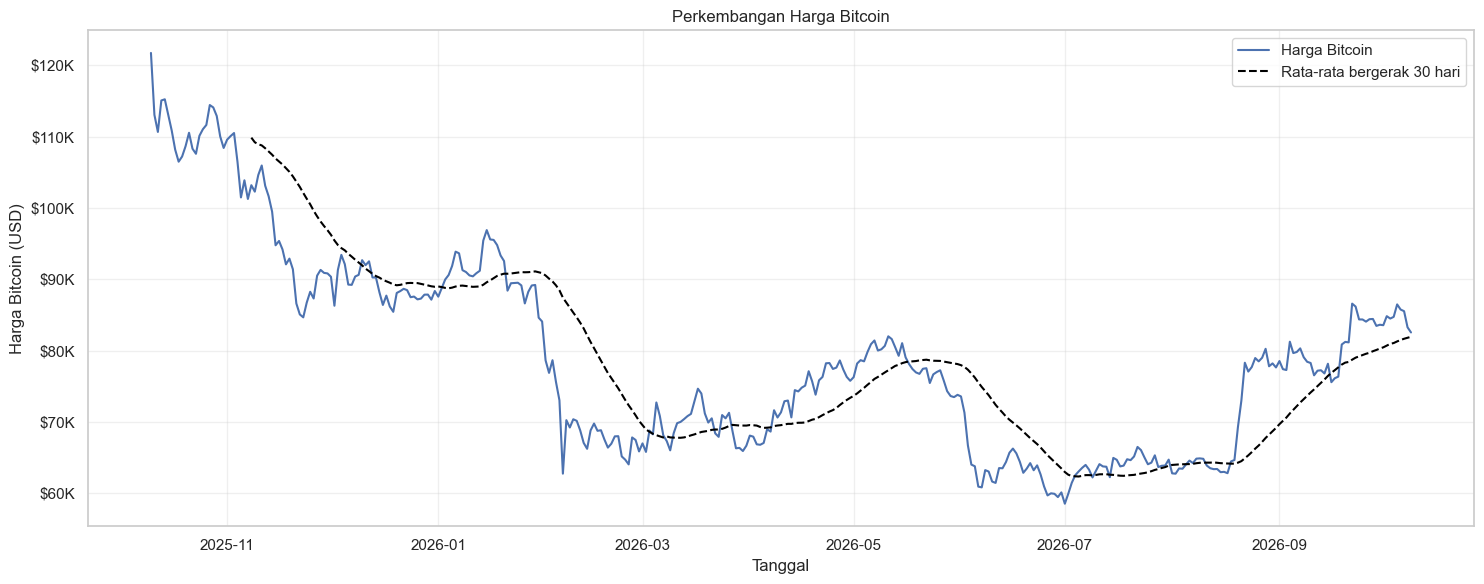

In [101]:
plt.figure(figsize=(15, 6))

plt.plot(
    df_btc["recorded_date"],
    df_btc["btc_price"],
    label="Harga Bitcoin"
)

plt.plot(
    df_btc["recorded_date"],
    df_btc["btc_price"].rolling(30).mean(),
    linestyle="--",
    color="black",
    label="Rata-rata bergerak 30 hari"
)

plt.title("Perkembangan Harga Bitcoin")
plt.xlabel("Tanggal")
plt.ylabel("Harga Bitcoin (USD)")

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

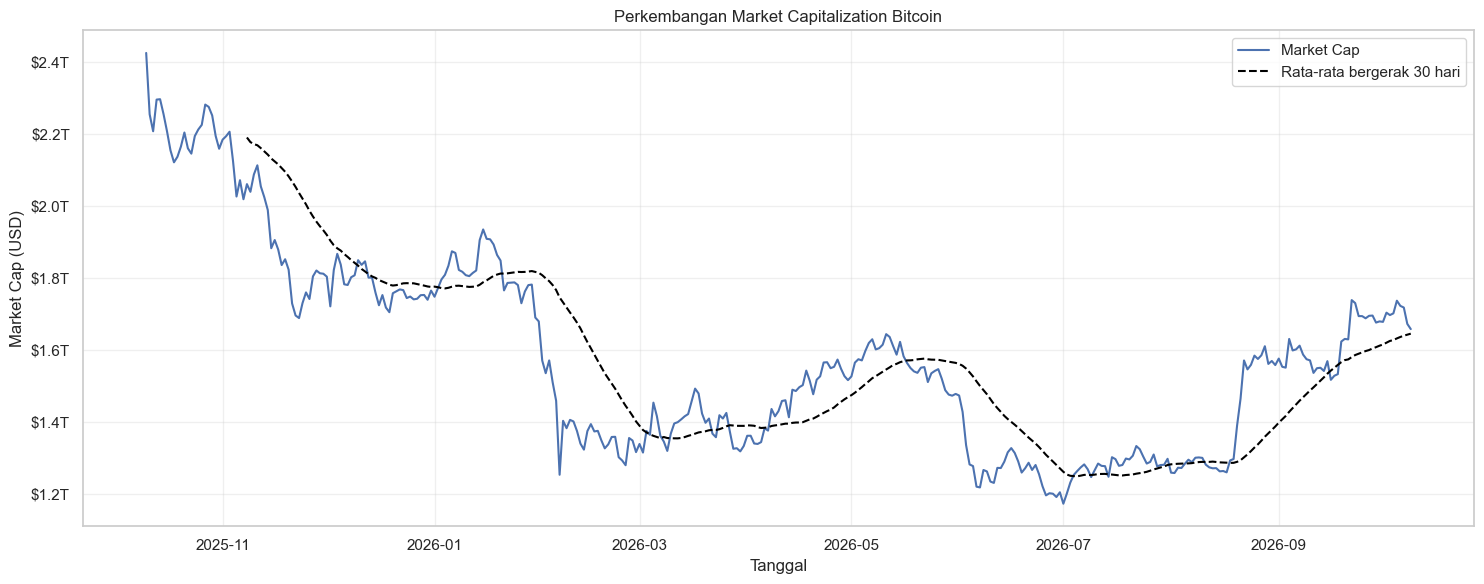

In [102]:
plt.figure(figsize=(15, 6))

plt.plot(
    df_btc["recorded_date"],
    df_btc["market_cap_usd"],
    label="Market Cap"
)

plt.plot(
    df_btc["recorded_date"],
    df_btc["market_cap_usd"].rolling(30).mean(),
    linestyle="--",
    color="black",
    label="Rata-rata bergerak 30 hari"
)

plt.title("Perkembangan Market Capitalization Bitcoin")
plt.xlabel("Tanggal")
plt.ylabel("Market Cap (USD)")

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

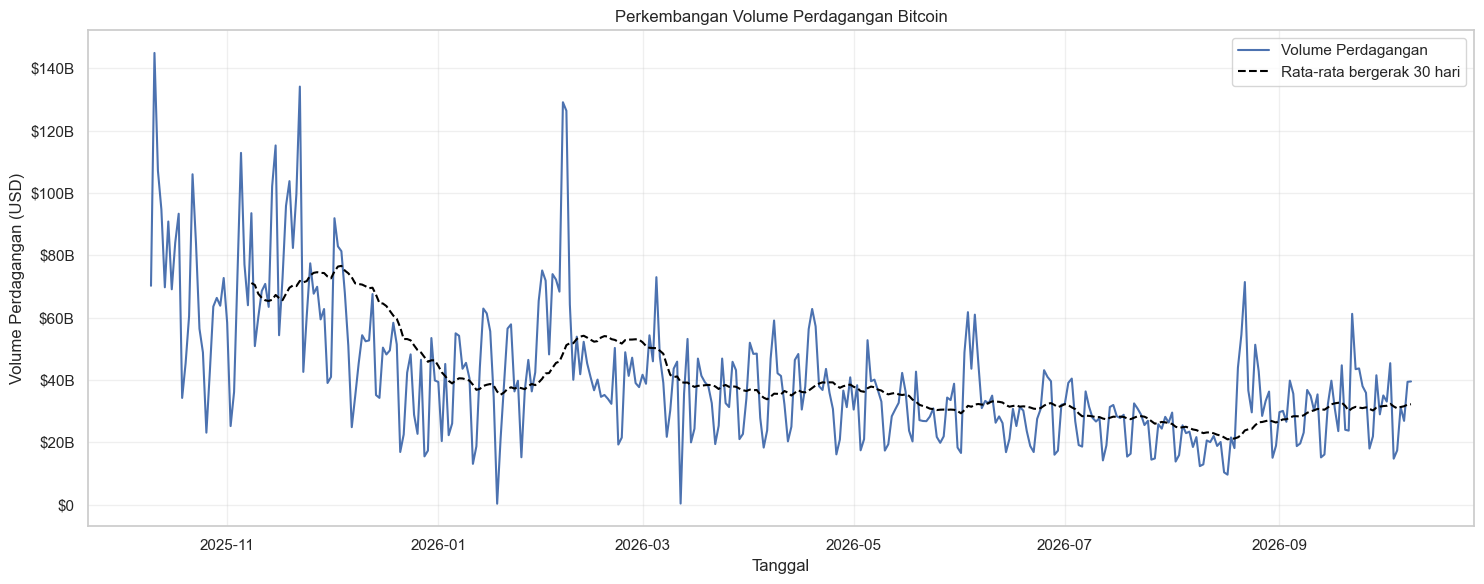

In [103]:
plt.figure(figsize=(15, 6))

plt.plot(
    df_btc["recorded_date"],
    df_btc["volume_usd"],
    label="Volume Perdagangan"
)

plt.plot(
    df_btc["recorded_date"],
    df_btc["volume_usd"].rolling(30).mean(),
    linestyle="--",
    color="black",
    label="Rata-rata bergerak 30 hari"
)

plt.title("Perkembangan Volume Perdagangan Bitcoin")
plt.xlabel("Tanggal")
plt.ylabel("Volume Perdagangan (USD)")

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

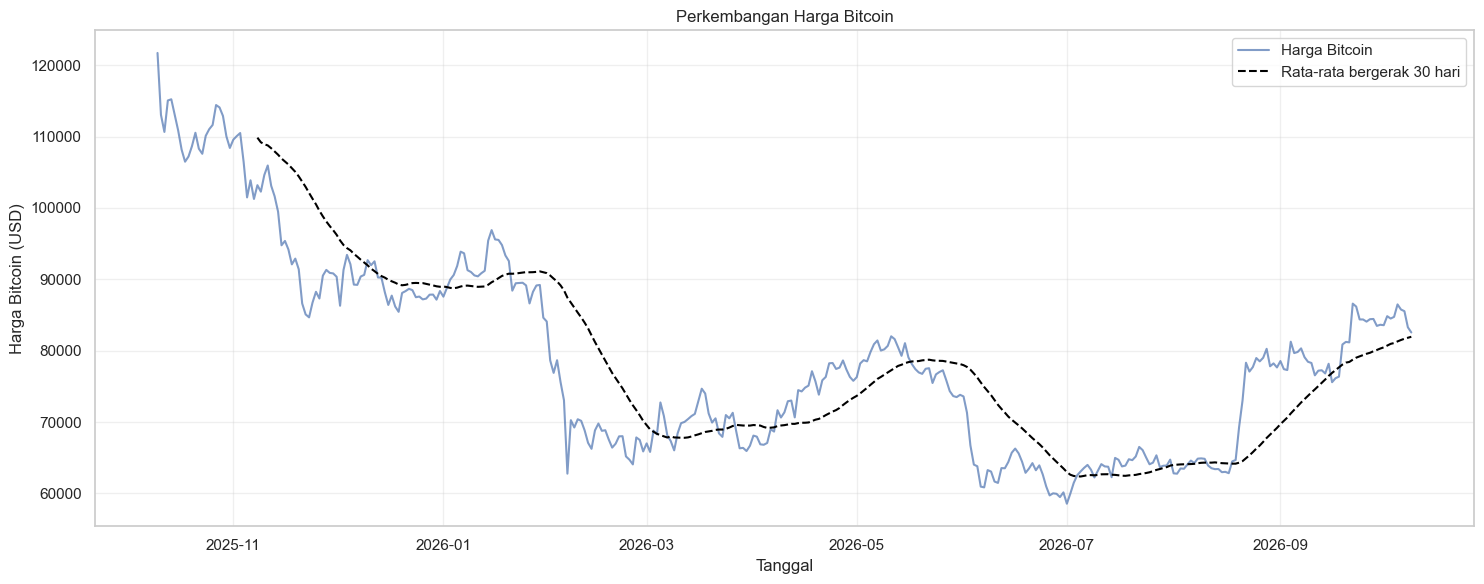

In [104]:

plt.figure(figsize=(15, 6))

plt.plot(
    df_btc["recorded_date"],
    df_btc["btc_price"],
    label="Harga Bitcoin",
    alpha=0.7
)

plt.plot(
    df_btc["recorded_date"],
    df_btc["btc_price"].rolling(30).mean(),
    linestyle="--",
    color="black",
    label="Rata-rata bergerak 30 hari"
)

plt.title("Perkembangan Harga Bitcoin")
plt.xlabel("Tanggal")
plt.ylabel("Harga Bitcoin (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Insight:
* Harga Bitcoin turun 32.17% dari 121,718.67 (2025-10-10) menjadi 82,560.57 (2026-10-09). Tertinggi 121,718.67 pada 2025-10-10, terendah 58,566.09 pada 2026-07-01. Koefisien variasi 17.6%.
* Market capitalization turun 31.60% dari 2,425,643,508,379.29 (2025-10-10) menjadi 1,659,046,462,748.75 (2026-10-09). Tertinggi 2,425,643,508,379.29 pada 2025-10-10, terendah 1,174,271,521,060.03 pada 2026-07-01. Koefisien variasi 17.4%.
* Volume perdagangan turun 43.68% dari 70,251,676,816.29 (2025-10-10) menjadi 39,567,263,858.60 (2026-10-09). Tertinggi 144,943,015,938.36 pada 2025-10-11, terendah 339,120,955.93 pada 2026-01-18. Koefisien variasi 54.3%.

Catatan: koefisien variasi yang lebih besar menunjukkan fluktuasi relatif yang lebih tinggi terhadap rata-ratanya.

**2. Bagaimana hubungan antara harga Bitcoin, market capitalization, volume perdagangan, dan circulating supply? Apakah terdapat korelasi yang kuat di antara variabel tersebut?**

Korelasi dihitung dengan tiga sudut pandang: Pearson pada level, Spearman pada level, dan Pearson pada perubahan harian.
Korelasi pada level yang sama-sama bertren dapat tampak tinggi tanpa hubungan yang berarti, sehingga korelasi pada
perubahan harian dibutuhkan sebagai pembanding.

In [105]:
# matriks korelasi
korelasi_pearson = df_btc[kolom_utama].corr(method="pearson")
korelasi_spearman = df_btc[kolom_utama].corr(method="spearman")

perubahan_harian = df_btc[kolom_utama].pct_change().replace([np.inf, -np.inf], np.nan).dropna()
korelasi_perubahan = perubahan_harian.corr(method="pearson")

print("Korelasi Pearson (level):")
display(korelasi_pearson)

print("Korelasi Spearman (level):")
display(korelasi_spearman)

print("Korelasi Pearson (perubahan harian):")
display(korelasi_perubahan)

Korelasi Pearson (level):


,btc_price,market_cap_usd,volume_usd
btc_price,1.0000,0.9999,0.4992
market_cap_usd,0.9999,1.0000,0.4960
volume_usd,0.4992,0.4960,1.0000


Korelasi Spearman (level):


,btc_price,market_cap_usd,volume_usd
btc_price,1.0000,0.9999,0.4643
market_cap_usd,0.9999,1.0000,0.4611
volume_usd,0.4643,0.4611,1.0000


Korelasi Pearson (perubahan harian):


,btc_price,market_cap_usd,volume_usd
btc_price,1.0000,0.9996,-0.0035
market_cap_usd,0.9996,1.0000,-0.0035
volume_usd,-0.0035,-0.0035,1.0000


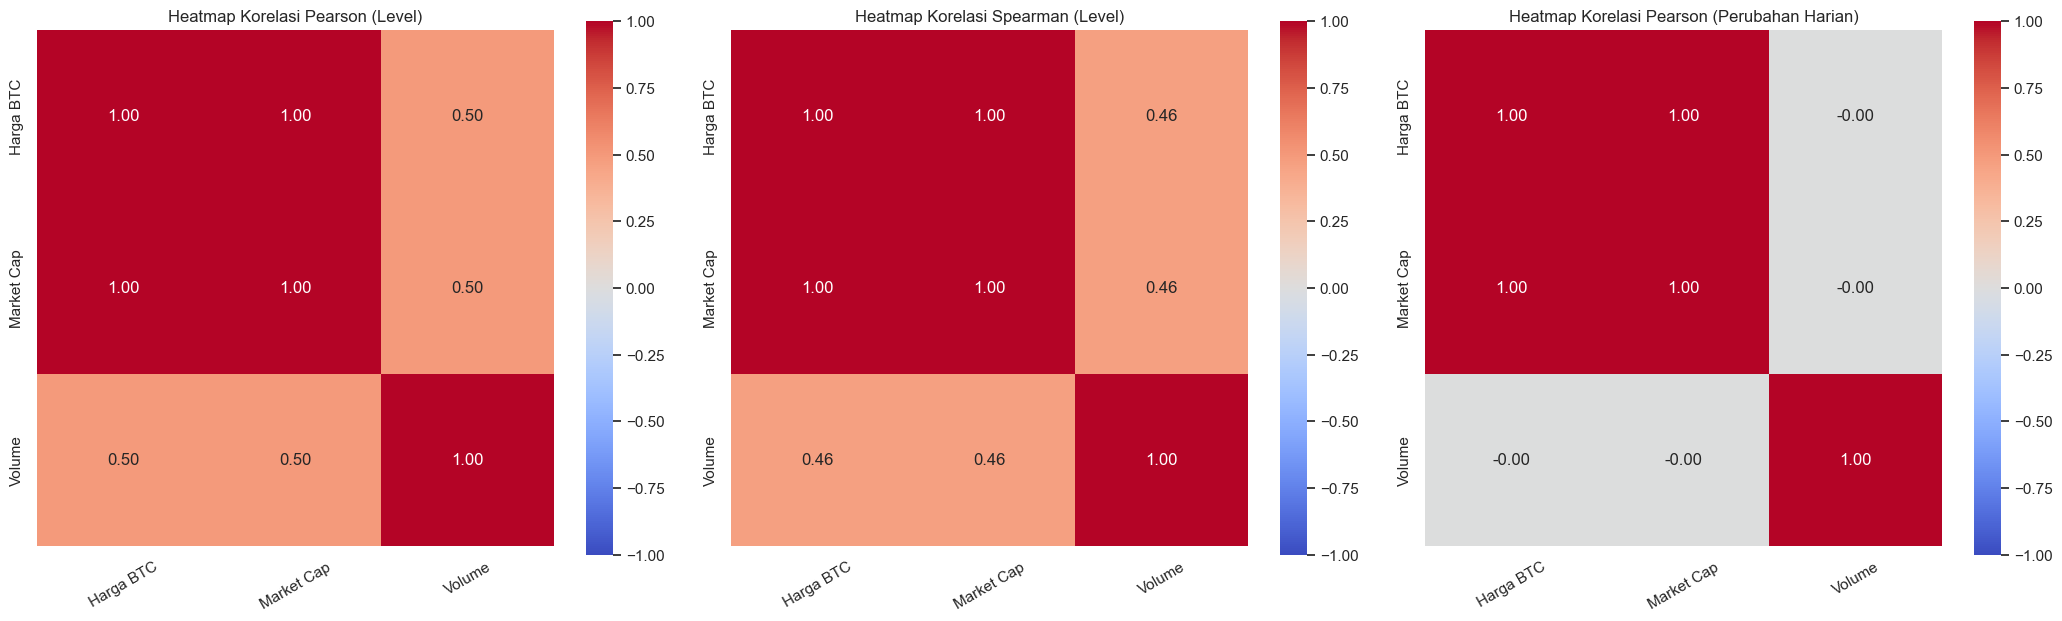

In [106]:
# heatmap korelasi
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (mat, judul) in zip(axes, [
    (korelasi_pearson, "Pearson (Level)"),
    (korelasi_spearman, "Spearman (Level)"),
    (korelasi_perubahan, "Pearson (Perubahan Harian)"),
]):
    sns.heatmap(
        mat.rename(index=LABEL_KOL, columns=LABEL_KOL),
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        ax=ax
    )
    ax.set_title(f"Heatmap Korelasi {judul}")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

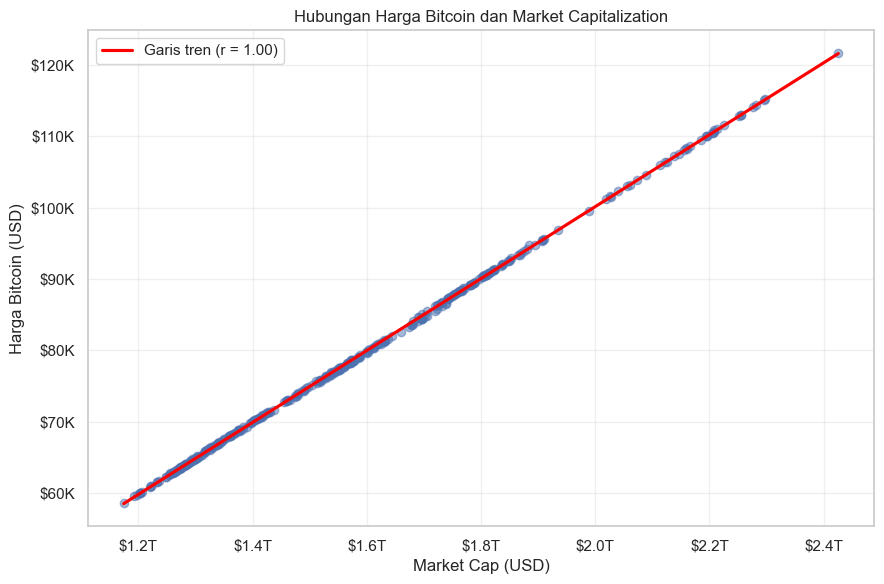

In [107]:
r = korelasi_pearson.loc["btc_price", "market_cap_usd"]

plt.figure(figsize=(9, 6))

sns.regplot(
    data=df_btc,
    x="market_cap_usd",
    y="btc_price",
    ci=None,
    scatter_kws={"alpha": 0.5, "label": "Pengamatan harian"},
    line_kws={"color": "red", "label": f"Garis tren (r = {r:.2f})"}
)

plt.title("Hubungan Harga Bitcoin dan Market Capitalization")
plt.xlabel("Market Cap (USD)")
plt.ylabel("Harga Bitcoin (USD)")

plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

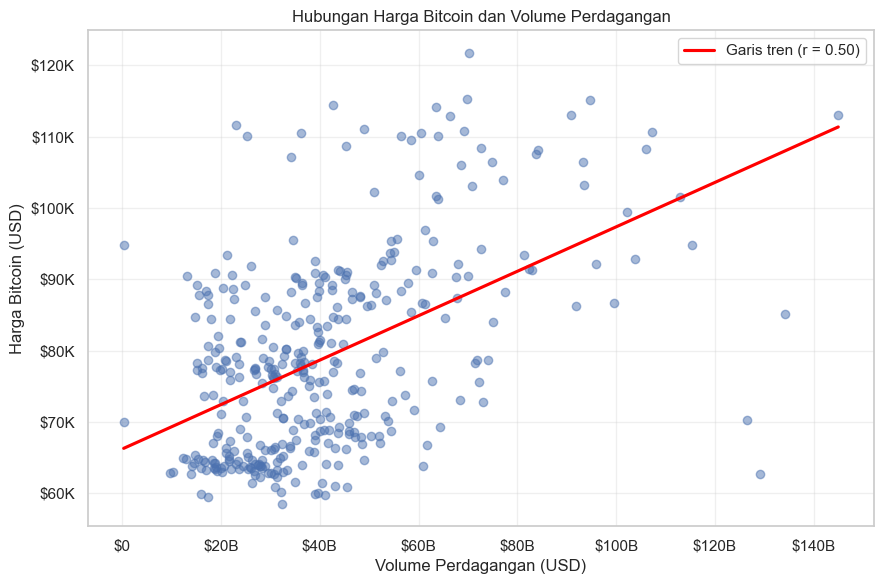

In [108]:
r = korelasi_pearson.loc["btc_price", "volume_usd"]

plt.figure(figsize=(9, 6))

sns.regplot(
    data=df_btc,
    x="volume_usd",
    y="btc_price",
    ci=None,
    scatter_kws={"alpha": 0.5, "label": "Pengamatan harian"},
    line_kws={"color": "red", "label": f"Garis tren (r = {r:.2f})"}
)

plt.title("Hubungan Harga Bitcoin dan Volume Perdagangan")
plt.xlabel("Volume Perdagangan (USD)")
plt.ylabel("Harga Bitcoin (USD)")

plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

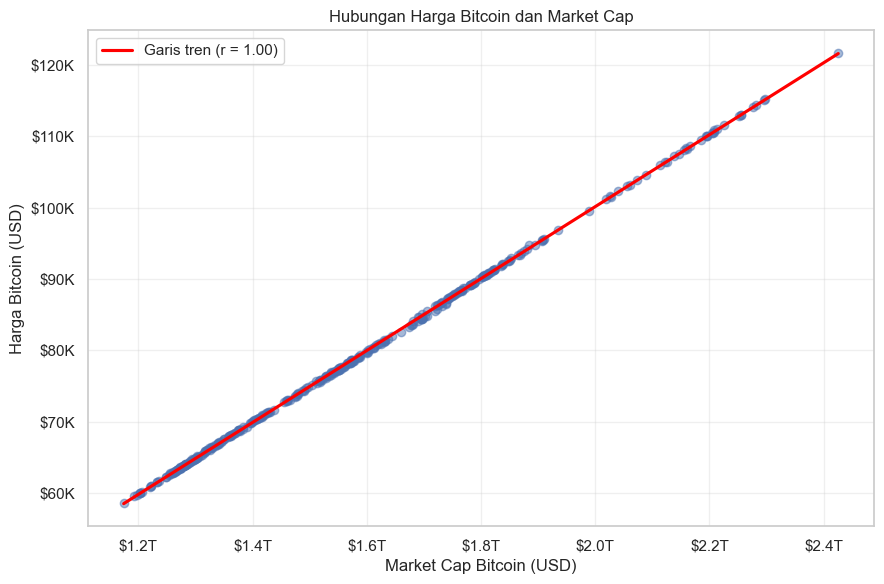

In [109]:

r = korelasi_pearson.loc["btc_price", "market_cap_usd"]

plt.figure(figsize=(9, 6))

sns.regplot(
    data=df_btc,
    x="market_cap_usd",
    y="btc_price",
    ci=None,
    scatter_kws={"alpha": 0.5, "label": "Pengamatan harian"},
    line_kws={"color": "red", "label": f"Garis tren (r = {r:.2f})"}
)

plt.title("Hubungan Harga Bitcoin dan Market Cap")
plt.xlabel("Market Cap Bitcoin (USD)")
plt.ylabel("Harga Bitcoin (USD)")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Insight:
* Market Cap:
    Pearson level = 0.9999 (sangat kuat, positif), Spearman level = 0.9999 (sangat kuat, positif)
    Pearson perubahan harian = 0.9996 (sangat kuat, positif)
* Volume:
    Pearson level = 0.4992 (sedang, positif), Spearman level = 0.4643 (sedang, positif)
    Pearson perubahan harian = -0.0035 (sangat lemah, negatif)

Batasan: korelasi mengukur keeratan hubungan statistik, bukan sebab-akibat. Korelasi pada level dapat terlihat tinggi karena kedua deret sama-sama memiliki tren (spurious correlation).

**3. Bagaimana karakteristik volatilitas dan perubahan harga Bitcoin dari waktu ke waktu, serta apakah perubahan volume perdagangan dan market capitalization berkaitan dengan perubahan harga Bitcoin pada periode berikutnya?**

Variabel pada tanggal *t* hanya dibandingkan dengan return pada tanggal *t+1* melalui `shift(-1)`, sehingga tidak ada
informasi masa depan yang masuk ke sisi prediktor.

In [110]:
# return harian, perubahan market cap dan volume, rolling volatility
analysis_data = df_btc.sort_values("recorded_date").reset_index(drop=True).copy()

analysis_data["return_harian"] = analysis_data["btc_price"].pct_change()
analysis_data["perubahan_market_cap"] = analysis_data["market_cap_usd"].pct_change()
analysis_data["perubahan_volume"] = analysis_data["volume_usd"].pct_change()

kolom_perubahan = ["return_harian", "perubahan_market_cap", "perubahan_volume"]
analysis_data[kolom_perubahan] = analysis_data[kolom_perubahan].replace([np.inf, -np.inf], np.nan)

# Rolling volatility = simpangan baku return harian
analysis_data["vol_7d"] = analysis_data["return_harian"].rolling(7).std()
analysis_data["vol_30d"] = analysis_data["return_harian"].rolling(30).std()

# Return hari berikutnya (return t+1 disejajarkan ke baris t)
analysis_data["return_berikutnya"] = analysis_data["return_harian"].shift(-1)

print("Contoh pergeseran waktu (return_berikutnya pada baris t = return_harian pada baris t+1):")
display(analysis_data[["recorded_date", "btc_price", "return_harian", "return_berikutnya"]].head(8))

Contoh pergeseran waktu (return_berikutnya pada baris t = return_harian pada baris t+1):


,recorded_date,btc_price,return_harian,return_berikutnya
0,2025-10-10,"121,718.6676",NaN,-0.0713
1,2025-10-11,"113,043.6759",-0.0713,-0.0211
2,2025-10-12,"110,655.2698",-0.0211,0.0398
3,2025-10-13,"115,060.8842",0.0398,0.0014
4,2025-10-14,"115,226.5843",0.0014,-0.0187
5,2025-10-15,"113,066.3508",-0.0187,-0.0197
6,2025-10-16,"110,844.4042",-0.0197,-0.0241
7,2025-10-17,"108,168.1735",-0.0241,-0.0156


In [111]:
# statistik return harian
r = analysis_data["return_harian"].dropna()
vol_harian = r.std()
vol_tahunan = vol_harian * np.sqrt(365)

display((r * 100).describe().to_frame("return_harian_%").T)

print(f"Skewness                 : {r.skew():.4f}")
print(f"Kurtosis (excess)        : {r.kurt():.4f}")
print(f"Volatilitas harian (std) : {vol_harian*100:.3f}%")
print(f"Volatilitas tahunan      : {vol_tahunan*100:.2f}% (std x akar 365)")

tabel_return = analysis_data.dropna(subset=["return_harian"])[["recorded_date", "btc_price", "return_harian"]]

print("\nLima kenaikan harian terbesar:")
display(tabel_return.nlargest(5, "return_harian"))

print("Lima penurunan harian terbesar:")
display(tabel_return.nsmallest(5, "return_harian"))

,count,mean,std,min,25%,50%,75%,max
return_harian_%,364.0000,-0.0793,2.3368,-14.0721,-1.4371,-0.0761,1.0344,11.9377


Skewness                 : 0.0160
Kurtosis (excess)        : 5.6674
Volatilitas harian (std) : 2.337%
Volatilitas tahunan      : 44.64% (std x akar 365)

Lima kenaikan harian terbesar:


,recorded_date,btc_price,return_harian
120,2026-02-07,"70,272.5222",0.1194
316,2026-08-22,"78,317.7772",0.0725
314,2026-08-20,"69,291.0104",0.0712
347,2026-09-22,"86,596.7400",0.0669
146,2026-03-05,"72,752.3016",0.0654


Lima penurunan harian terbesar:


,recorded_date,btc_price,return_harian
119,2026-02-06,"62,778.2176",-0.1407
1,2025-10-11,"113,043.6759",-0.0713
114,2026-02-01,"78,647.0274",-0.0647
236,2026-06-03,"66,727.2642",-0.0644
42,2025-11-21,"86,618.4716",-0.0524


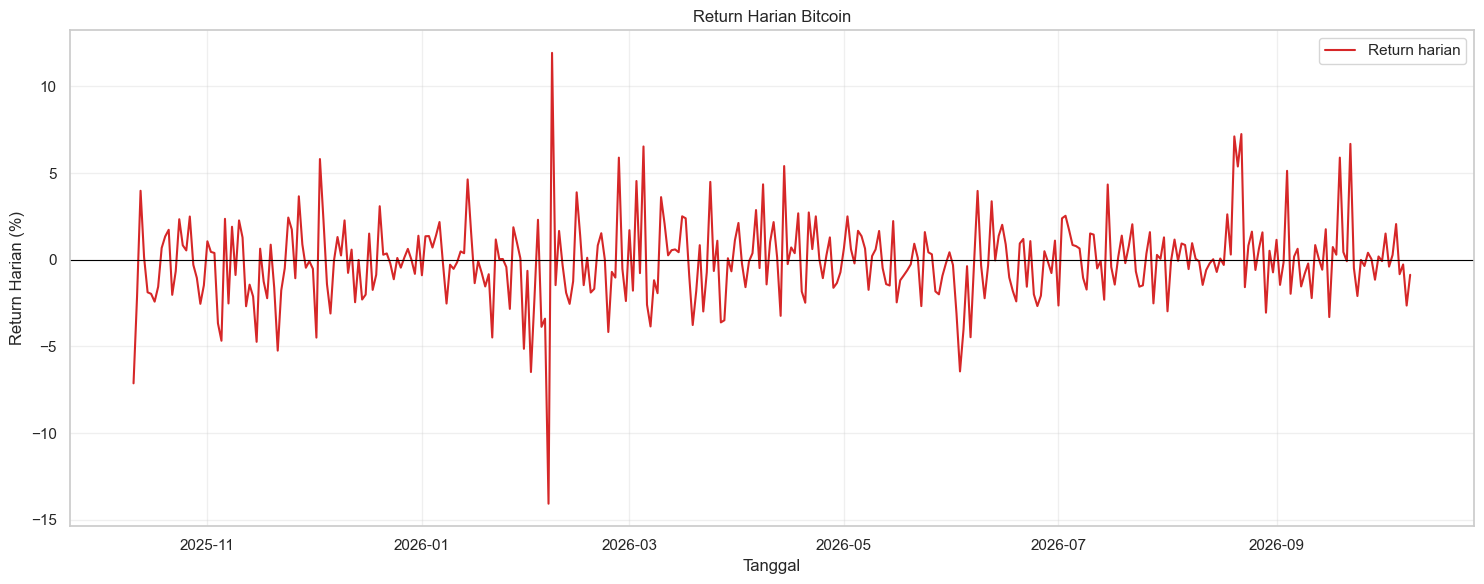

In [112]:
# grafik return harian
plt.figure(figsize=(15, 6))

plt.plot(
    analysis_data["recorded_date"],
    analysis_data["return_harian"] * 100,
    color="tab:red",
    label="Return harian"
)

plt.axhline(0, color="black", linewidth=0.8)

plt.title("Return Harian Bitcoin")
plt.xlabel("Tanggal")
plt.ylabel("Return Harian (%)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

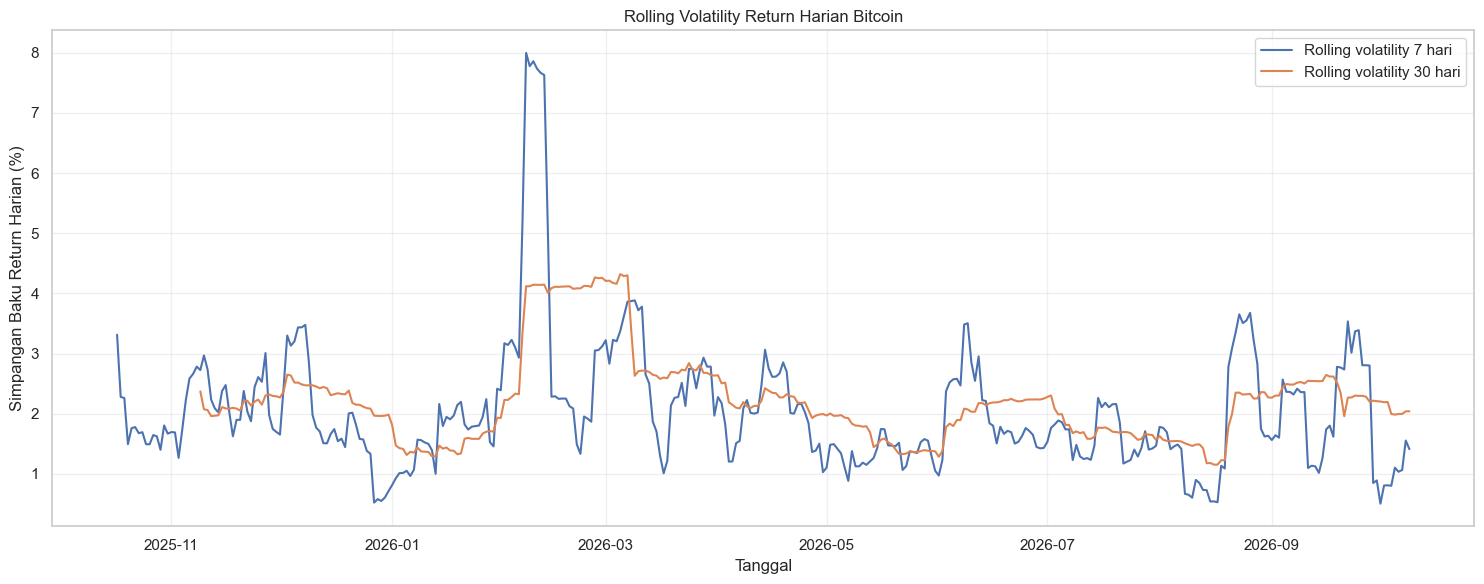

In [113]:
# grafik rolling volatility
plt.figure(figsize=(15, 6))

plt.plot(
    analysis_data["recorded_date"],
    analysis_data["vol_7d"] * 100,
    label="Rolling volatility 7 hari"
)

plt.plot(
    analysis_data["recorded_date"],
    analysis_data["vol_30d"] * 100,
    label="Rolling volatility 30 hari"
)

plt.title("Rolling Volatility Return Harian Bitcoin")
plt.xlabel("Tanggal")
plt.ylabel("Simpangan Baku Return Harian (%)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

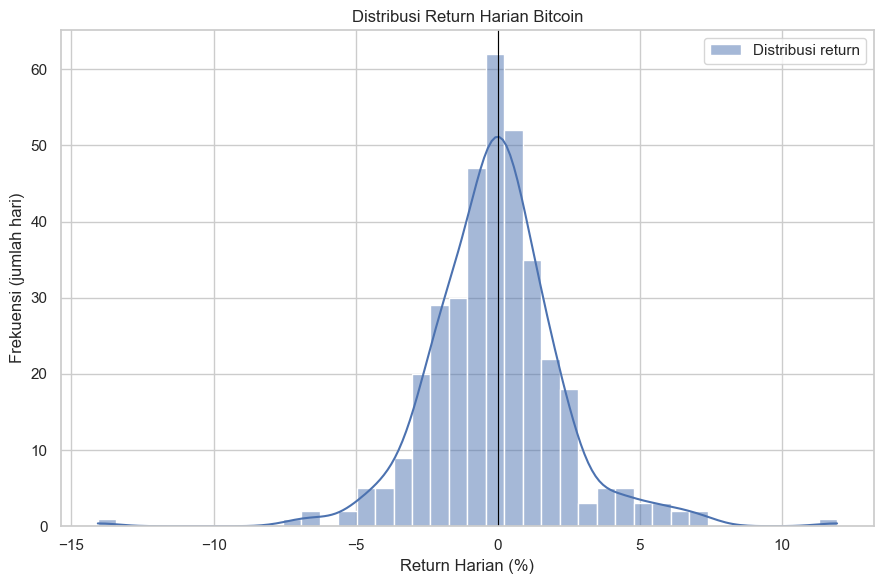

In [114]:
# distribusi return harian
plt.figure(figsize=(9, 6))

sns.histplot(r * 100, bins=40, kde=True, label="Distribusi return")
plt.axvline(0, color="black", linewidth=0.8)

plt.title("Distribusi Return Harian Bitcoin")
plt.xlabel("Return Harian (%)")
plt.ylabel("Frekuensi (jumlah hari)")

plt.legend()
plt.tight_layout()
plt.show()

In [115]:
# hubungan perubahan hari t dengan return hari t+1
def uji_korelasi(x, y):
    d = pd.concat([x, y], axis=1).dropna()
    if len(d) < 10:
        return {"r_pearson": np.nan, "p_pearson": np.nan, "rho_spearman": np.nan, "p_spearman": np.nan, "n": len(d)}
    rp, pp = stats.pearsonr(d.iloc[:, 0], d.iloc[:, 1])
    rs, ps = stats.spearmanr(d.iloc[:, 0], d.iloc[:, 1])
    return {"r_pearson": rp, "p_pearson": pp, "rho_spearman": rs, "p_spearman": ps, "n": len(d)}


hasil_uji = pd.DataFrame({
    "Perubahan volume (t) -> return (t+1)": uji_korelasi(analysis_data["perubahan_volume"], analysis_data["return_berikutnya"]),
    "Perubahan market cap (t) -> return (t+1)": uji_korelasi(analysis_data["perubahan_market_cap"], analysis_data["return_berikutnya"]),
    "Return (t) -> return (t+1) [pembanding]": uji_korelasi(analysis_data["return_harian"], analysis_data["return_berikutnya"]),
}).T

display(hasil_uji)

,r_pearson,p_pearson,rho_spearman,p_spearman,n
Perubahan volume (t) -> return (t+1),0.0010,0.9852,-0.0965,0.0662,363.0000
Perubahan market cap (t) -> return (t+1),-0.0081,0.8777,0.0444,0.3987,363.0000
Return (t) -> return (t+1) [pembanding],-0.0064,0.9032,0.0464,0.3777,363.0000


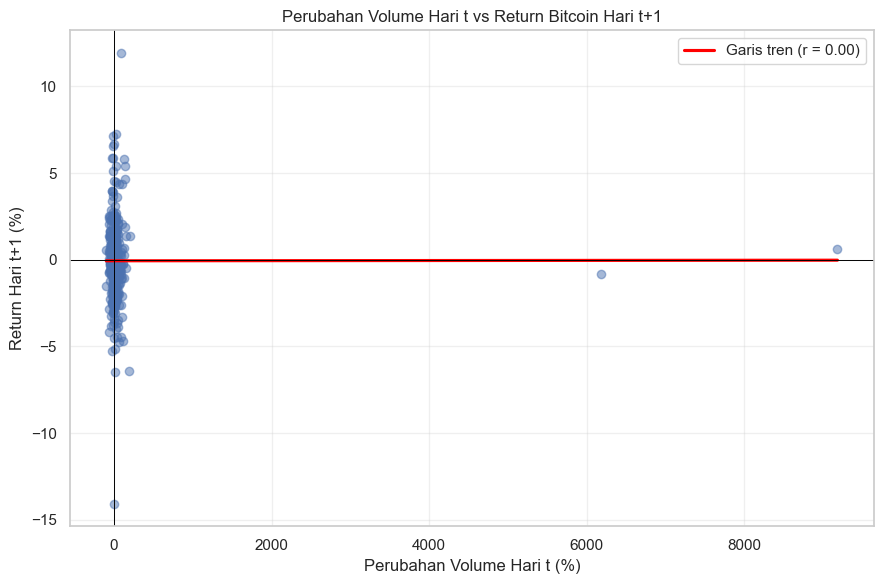

In [116]:
d = analysis_data[["perubahan_volume", "return_berikutnya"]].dropna() * 100
r_plot = d.corr().iloc[0, 1]

plt.figure(figsize=(9, 6))

sns.regplot(
    data=d,
    x="perubahan_volume",
    y="return_berikutnya",
    ci=None,
    scatter_kws={"alpha": 0.5, "label": "Pengamatan harian"},
    line_kws={"color": "red", "label": f"Garis tren (r = {r_plot:.2f})"}
)

plt.axhline(0, color="black", linewidth=0.7)
plt.axvline(0, color="black", linewidth=0.7)

plt.title("Perubahan Volume Hari t vs Return Bitcoin Hari t+1")
plt.xlabel("Perubahan Volume Hari t (%)")
plt.ylabel("Return Hari t+1 (%)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

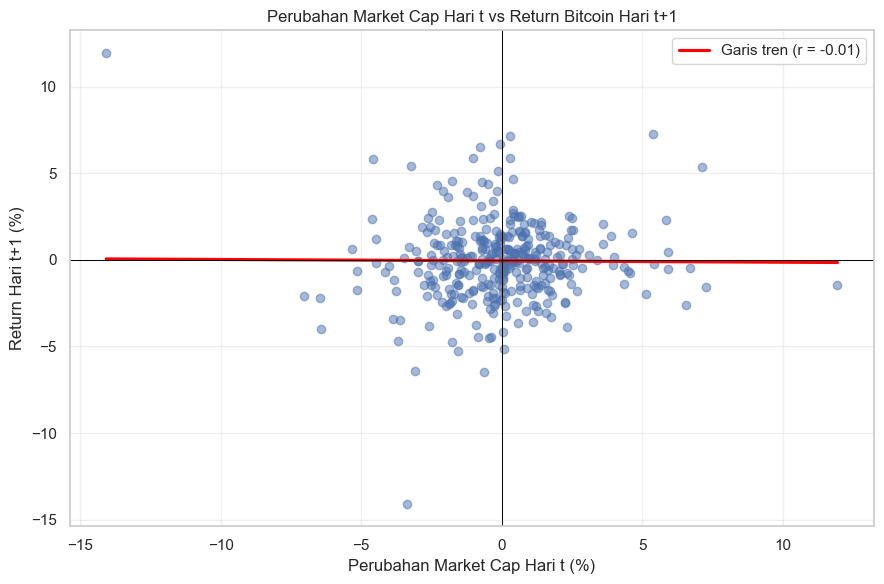

In [117]:
d = analysis_data[["perubahan_market_cap", "return_berikutnya"]].dropna() * 100
r_plot = d.corr().iloc[0, 1]

plt.figure(figsize=(9, 6))

sns.regplot(
    data=d,
    x="perubahan_market_cap",
    y="return_berikutnya",
    ci=None,
    scatter_kws={"alpha": 0.5, "label": "Pengamatan harian"},
    line_kws={"color": "red", "label": f"Garis tren (r = {r_plot:.2f})"}
)

plt.axhline(0, color="black", linewidth=0.7)
plt.axvline(0, color="black", linewidth=0.7)

plt.title("Perubahan Market Cap Hari t vs Return Bitcoin Hari t+1")
plt.xlabel("Perubahan Market Cap Hari t (%)")
plt.ylabel("Return Hari t+1 (%)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Bulan dengan volatilitas tertinggi:


,std_return,rata_return,hari
bulan,,,
2026-02,0.0433,-0.0078,28
2026-03,0.0261,0.0007,31
2025-10,0.0238,-0.0052,21


Bulan dengan volatilitas terendah:


,std_return,rata_return,hari
bulan,,,
2026-05,0.0136,-0.0008,31
2026-07,0.0163,0.0025,31
2026-01,0.0190,-0.0014,31


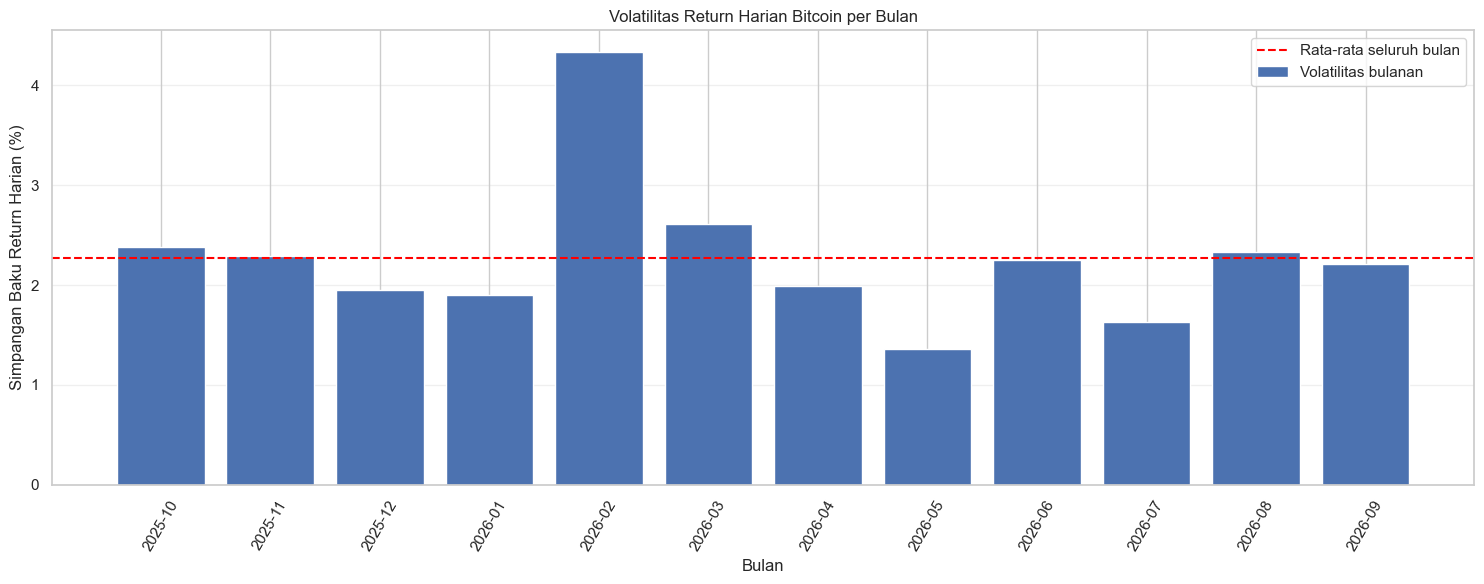

In [118]:
# volatilitas bulanan (hanya bulan dengan minimal 10 hari data)
d_bulan = analysis_data.dropna(subset=["return_harian"]).copy()
d_bulan["bulan"] = d_bulan["recorded_date"].dt.to_period("M")

vol_bulanan = d_bulan.groupby("bulan").agg(
    std_return=("return_harian", "std"),
    rata_return=("return_harian", "mean"),
    hari=("return_harian", "size")
)
vol_bulanan = vol_bulanan[vol_bulanan["hari"] >= 10].dropna()

if len(vol_bulanan) >= 2:
    k = min(3, len(vol_bulanan))

    print("Bulan dengan volatilitas tertinggi:")
    display(vol_bulanan.nlargest(k, "std_return"))

    print("Bulan dengan volatilitas terendah:")
    display(vol_bulanan.nsmallest(k, "std_return"))

    plt.figure(figsize=(15, 6))

    plt.bar(vol_bulanan.index.astype(str), vol_bulanan["std_return"] * 100, label="Volatilitas bulanan")
    plt.axhline(vol_bulanan["std_return"].mean() * 100, color="red", linestyle="--", label="Rata-rata seluruh bulan")

    plt.title("Volatilitas Return Harian Bitcoin per Bulan")
    plt.xlabel("Bulan")
    plt.ylabel("Simpangan Baku Return Harian (%)")

    plt.xticks(rotation=60)
    plt.legend()
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
else:
    print("Jumlah bulan dengan data memadai kurang dari 2, perbandingan volatilitas bulanan tidak dapat dilakukan.")

### Insight:
* Volatilitas harian Bitcoin 2.34% (setara sekitar 44.6% per tahun).
* Skewness return 0.016 dan kurtosis 5.667. Kurtosis positif menandakan ekor distribusi lebih tebal dari distribusi normal.
* Fluktuasi relatif tertinggi terjadi pada 2026-02 (4.33% per hari), terendah pada 2026-05 (1.36% per hari).
* Perubahan volume (t) -> return (t+1): Pearson r = 0.001 (sangat lemah, positif; p = 0.985, tidak signifikan pada alpha 5%), Spearman rho = -0.097, n = 363.
* Perubahan market cap (t) -> return (t+1): Pearson r = -0.008 (sangat lemah, negatif; p = 0.878, tidak signifikan pada alpha 5%), Spearman rho = 0.044, n = 363.
* Return (t) -> return (t+1) [pembanding]: Pearson r = -0.006 (sangat lemah, negatif; p = 0.903, tidak signifikan pada alpha 5%), Spearman rho = 0.046, n = 363.

Catatan: hubungan yang lemah atau tidak signifikan berarti perubahan volume dan market cap hari ini tidak cukup untuk memprediksi return besok secara linier. Korelasi tidak menunjukkan sebab-akibat.

**4. Seberapa akurat algoritma XGBoost dalam memprediksi harga penutupan Bitcoin untuk satu hari berikutnya?**

* **Target prediksi:** harga Bitcoin satu hari berikutnya, `target_price_next_day = btc_price.shift(-1)`.
* **Fitur historis:** harga saat ini, lag harga (1, 3, 7, 14 hari), return historis, rolling mean dan standar deviasi (7 dan 30 hari), market cap, volume, circulating supply, serta lag market cap dan volume.
* **Alasan memakai XGBoost:** mampu mempelajari hubungan nonlinier dan interaksi antarfitur tanpa asumsi bentuk fungsi tertentu, serta memiliki regularisasi.
* **Data latih dan uji:** dibagi berdasarkan urutan waktu, 80% data awal untuk pelatihan dan 20% data akhir untuk pengujian.
* **Risiko data leakage:** pengacakan data, fitur dengan `shift` negatif, rolling window yang menyertakan data setelah tanggal prediksi, interpolasi dua arah, dan tuning yang memakai data uji akan membocorkan informasi masa depan.

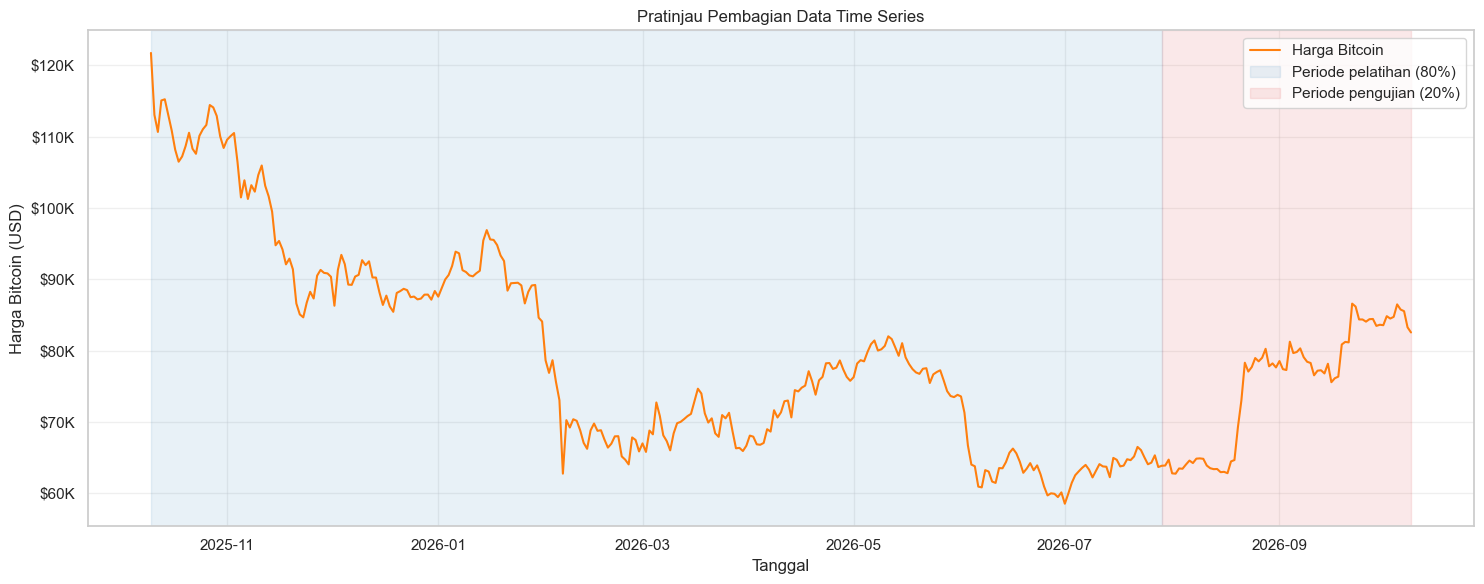

Autokorelasi lag-1 harga  : 0.9912
Autokorelasi lag-1 return : -0.0064

Insight: autokorelasi harga yang sangat tinggi menunjukkan harga hari ini adalah prediktor kuat harga besok. Karena itu baseline 'harga besok = harga hari ini' adalah pembanding yang menantang dan R2 saja tidak cukup untuk menilai model.


In [119]:
# pratinjau pembagian waktu 80:20 dan pemeriksaan autokorelasi
idx_pratinjau = int(len(df_btc) * 0.8)
tgl_potong = df_btc["recorded_date"].iloc[idx_pratinjau]

plt.figure(figsize=(15, 6))

plt.plot(df_btc["recorded_date"], df_btc["btc_price"], color="tab:orange", label="Harga Bitcoin")
plt.axvspan(df_btc["recorded_date"].iloc[0], tgl_potong, color="tab:blue", alpha=0.10, label="Periode pelatihan (80%)")
plt.axvspan(tgl_potong, df_btc["recorded_date"].iloc[-1], color="tab:red", alpha=0.10, label="Periode pengujian (20%)")

plt.title("Pratinjau Pembagian Data Time Series")
plt.xlabel("Tanggal")
plt.ylabel("Harga Bitcoin (USD)")

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Autokorelasi lag-1 harga  : {df_btc['btc_price'].autocorr(1):.4f}")
print(f"Autokorelasi lag-1 return : {analysis_data['return_harian'].autocorr(1):.4f}")
print("\nInsight: autokorelasi harga yang sangat tinggi menunjukkan harga hari ini adalah prediktor kuat harga besok. "
      "Karena itu baseline 'harga besok = harga hari ini' adalah pembanding yang menantang dan R2 saja tidak cukup untuk menilai model.")

# Feature Engineering untuk XGBoost

Semua fitur pada baris tanggal *t* dihitung hanya dari data tanggal *t* dan sebelumnya. Target dibuat dengan `shift(-1)`
dan hanya berlaku jika selisih ke tanggal berikutnya tepat 1 hari.

In [120]:
TARGET = "target_price_next_day"
LAG_HARGA = [1, 3, 7, 14]
LAG_LAIN = [1, 3, 7]
JENDELA = [7, 30]

feature_data = df_btc.sort_values("recorded_date").reset_index(drop=True).copy()

if len(feature_data) < 60:
    raise ValueError(f"Data hanya {len(feature_data)} baris. Minimal sekitar 60 baris untuk lag 14 hari dan rolling 30 hari.")

# Lag harga
for k in LAG_HARGA:
    feature_data[f"price_lag_{k}"] = feature_data["btc_price"].shift(k)

# Return historis (hanya memakai harga hingga hari t)
for h in [1, 3, 7]:
    feature_data[f"return_{h}d"] = feature_data["btc_price"].pct_change(h)

feature_data["return_lag_1"] = feature_data["return_1d"].shift(1)

# Rolling mean dan standar deviasi harga (jendela ke belakang)
for w in JENDELA:
    feature_data[f"price_roll_mean_{w}"] = feature_data["btc_price"].rolling(w).mean()
    feature_data[f"price_roll_std_{w}"] = feature_data["btc_price"].rolling(w).std()

# Lag market cap dan volume
for k in LAG_LAIN:
    feature_data[f"market_cap_lag_{k}"] = feature_data["market_cap_usd"].shift(k)
    feature_data[f"volume_lag_{k}"] = feature_data["volume_usd"].shift(k)

# Target: harga hari berikutnya (valid jika tanggal berikutnya tepat 1 hari setelahnya)
feature_data[TARGET] = feature_data["btc_price"].shift(-1)
gap_depan = (feature_data["recorded_date"].shift(-1) - feature_data["recorded_date"]).dt.days
target_tidak_harian = gap_depan.notna() & (gap_depan != 1)
feature_data.loc[target_tidak_harian, TARGET] = np.nan

print("Baris dengan target dibatalkan (tanggal berikutnya bukan 1 hari):", int(target_tidak_harian.sum()))

FITUR = [c for c in feature_data.columns if c not in ["recorded_date", TARGET]]
feature_data[FITUR] = feature_data[FITUR].replace([np.inf, -np.inf], np.nan)

assert TARGET not in FITUR, "Target tidak boleh menjadi fitur."

# Buang baris yang tidak dapat dipakai (tanpa interpolasi)
n_sebelum = len(feature_data)
n_fitur_tidak_lengkap = int(feature_data[FITUR].isnull().any(axis=1).sum())

model_data = feature_data.dropna(subset=FITUR + [TARGET]).reset_index(drop=True)
n_sesudah = len(model_data)

print("\nJumlah fitur               :", len(FITUR))
print("Daftar fitur               :", FITUR)
print("\nJumlah baris sebelum       :", n_sebelum)
print("Baris fitur tidak lengkap  :", n_fitur_tidak_lengkap)
print("Jumlah baris sesudah       :", n_sesudah, f"(dibuang: {n_sebelum - n_sesudah})")

Baris dengan target dibatalkan (tanggal berikutnya bukan 1 hari): 0

Jumlah fitur               : 21
Daftar fitur               : ['btc_price', 'market_cap_usd', 'volume_usd', 'price_lag_1', 'price_lag_3', 'price_lag_7', 'price_lag_14', 'return_1d', 'return_3d', 'return_7d', 'return_lag_1', 'price_roll_mean_7', 'price_roll_std_7', 'price_roll_mean_30', 'price_roll_std_30', 'market_cap_lag_1', 'volume_lag_1', 'market_cap_lag_3', 'volume_lag_3', 'market_cap_lag_7', 'volume_lag_7']

Jumlah baris sebelum       : 365
Baris fitur tidak lengkap  : 29
Jumlah baris sesudah       : 335 (dibuang: 30)


In [121]:
# bukti tidak ada kebocoran: price_lag_k pada baris t = btc_price pada baris t-k, target pada baris t = btc_price pada t+1
display(feature_data[["recorded_date", "btc_price", "price_lag_1", "price_lag_7", TARGET]].iloc[14:20])

print("Contoh hasil feature engineering:")
display(model_data.head())

,recorded_date,btc_price,price_lag_1,price_lag_7,target_price_next_day
14,2025-10-24,"110,109.3052","107,591.4605","108,168.1735","111,030.1834"
15,2025-10-25,"111,030.1834","110,109.3052","106,483.8914","111,631.6373"
16,2025-10-26,"111,631.6373","111,030.1834","107,210.0961","114,419.2217"
17,2025-10-27,"114,419.2217","111,631.6373","108,655.5053","114,085.3312"
18,2025-10-28,"114,085.3312","114,419.2217","110,535.8630","112,893.8520"
19,2025-10-29,"112,893.8520","114,085.3312","108,301.7546","110,026.0876"


Contoh hasil feature engineering:


,recorded_date,btc_price,market_cap_usd,volume_usd,price_lag_1,price_lag_3,price_lag_7,price_lag_14,return_1d,return_3d,return_7d,return_lag_1,price_roll_mean_7,price_roll_std_7,price_roll_mean_30,price_roll_std_30,market_cap_lag_1,volume_lag_1,market_cap_lag_3,volume_lag_3,market_cap_lag_7,volume_lag_7,target_price_next_day
0,2025-11-08,"103,191.7561","2,061,483,488,853.8999","93,538,572,265.2200","101,261.6455","101,480.7666","109,566.6066","111,030.1834",0.0191,0.0169,-0.0582,-0.0252,"105,261.6103","3,839.1373","109,852.1820","4,316.5297","2,019,505,617,727.3501","64,007,649,509.2000","2,027,117,373,395.1699","112,885,195,780.5500","2,184,958,376,796.8799","58,440,602,313.4900","102,286.8252"
1,2025-11-09,"102,286.8252","2,040,163,403,275.1699","50,894,858,647.5100","103,191.7561","103,878.9336","110,066.9417","111,631.6373",-0.0088,-0.0153,-0.0707,0.0191,"104,150.1651","3,305.1680","109,204.4539","3,913.6147","2,061,483,488,853.8999","93,538,572,265.2200","2,072,420,580,091.9099","77,092,678,814.2200","2,194,472,770,726.0200","25,245,930,840.4900","104,610.2285"
2,2025-11-10,"104,610.2285","2,088,246,864,454.0901","60,194,546,960.3400","102,286.8252","101,261.6455","110,499.5224","114,419.2217",0.0227,0.0331,-0.0533,-0.0088,"103,308.8374","1,847.8505","108,923.3390","3,931.1819","2,040,163,403,275.1699","50,894,858,647.5100","2,019,505,617,727.3501","64,007,649,509.2000","2,206,951,286,346.5098","36,196,258,871.7400","105,951.4960"
3,2025-11-11,"105,951.4960","2,113,691,346,622.1799","68,564,010,180.8300","104,610.2285","103,191.7561","106,451.7065","114,085.3312",0.0128,0.0267,-0.0047,0.0227,"103,237.3788","1,710.6326","108,766.5465","3,953.4633","2,088,246,864,454.0901","60,194,546,960.3400","2,061,483,488,853.8999","93,538,572,265.2200","2,125,234,946,159.2800","74,958,013,879.9100","103,112.2101"
4,2025-11-12,"103,112.2101","2,055,081,880,355.9500","70,852,634,666.8400","105,951.4960","102,286.8252","101,480.7666","112,893.8520",-0.0268,0.0081,0.0161,0.0128,"103,470.4421","1,533.3696","108,368.2574","3,898.9835","2,113,691,346,622.1799","68,564,010,180.8300","2,040,163,403,275.1699","50,894,858,647.5100","2,027,117,373,395.1699","112,885,195,780.5500","101,633.6943"


,count,mean,std,min,25%,50%,75%,max
target_price_next_day,335.0000,"76,220.7704","10,747.3844","58,566.0920","66,275.5154","76,296.7965","85,495.1334","105,951.4960"


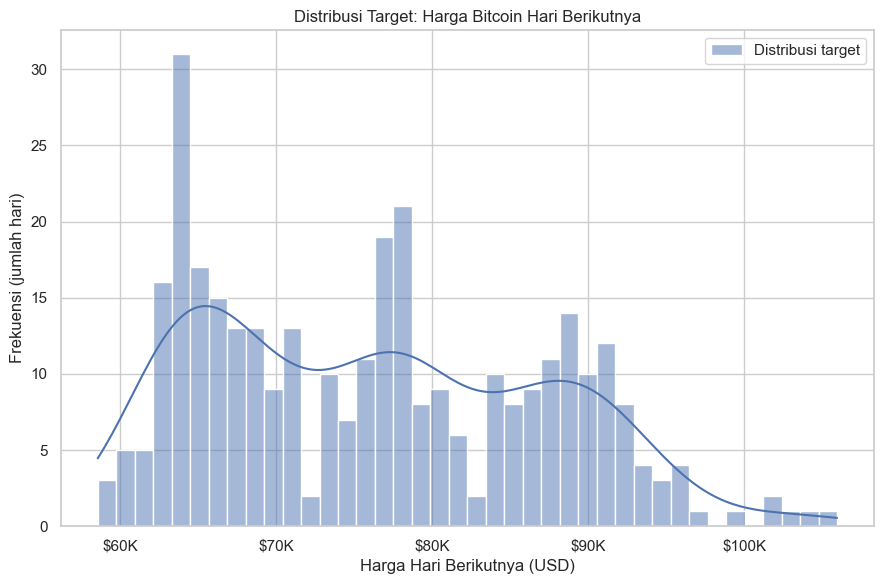

In [122]:
# distribusi target
display(model_data[TARGET].describe().to_frame().T)

plt.figure(figsize=(9, 6))

sns.histplot(model_data[TARGET], bins=40, kde=True, label="Distribusi target")

plt.title("Distribusi Target: Harga Bitcoin Hari Berikutnya")
plt.xlabel("Harga Hari Berikutnya (USD)")
plt.ylabel("Frekuensi (jumlah hari)")

plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
plt.legend()
plt.tight_layout()
plt.show()

# Train-Test Split

In [123]:
# SPLIT DATA (80% TRAIN - 20% TEST), URUTAN WAKTU DIPERTAHANKAN

model_data = model_data.sort_values("recorded_date").reset_index(drop=True)

split_index = int(len(model_data) * 0.8)

train = model_data.iloc[:split_index].copy()
test = model_data.iloc[split_index:].copy()

X_train, y_train = train[FITUR], train[TARGET]
X_test, y_test = test[FITUR], test[TARGET]

print("Data training :", train.shape)
print("Data testing  :", test.shape)
print("\nPeriode training:", train["recorded_date"].min().date(), "sampai", train["recorded_date"].max().date())
print("Periode testing :", test["recorded_date"].min().date(), "sampai", test["recorded_date"].max().date())

assert train["recorded_date"].max() < test["recorded_date"].min(), "Ada tanggal training yang lebih baru dari tanggal testing!"
print("\nValidasi: tidak ada tanggal training yang lebih baru daripada tanggal testing.")

# Pemeriksaan batas ekstrapolasi model berbasis pohon
persen_uji_luar_rentang = ((y_test > y_train.max()) | (y_test < y_train.min())).mean() * 100

print(f"\nRentang target training: {y_train.min():,.2f} - {y_train.max():,.2f}")
print(f"Rentang target testing : {y_test.min():,.2f} - {y_test.max():,.2f}")
print(f"Persentase target testing di luar rentang target training: {persen_uji_luar_rentang:.2f}%")

Data training : (268, 23)
Data testing  : (67, 23)

Periode training: 2025-11-08 sampai 2026-08-02
Periode testing : 2026-08-03 sampai 2026-10-08

Validasi: tidak ada tanggal training yang lebih baru daripada tanggal testing.

Rentang target training: 58,566.09 - 105,951.50
Rentang target testing : 62,843.70 - 86,596.74
Persentase target testing di luar rentang target training: 0.00%


# Modeling

**Baseline dan pemilihan hyperparameter**

Baseline memprediksi harga besok sama dengan harga hari ini. Tuning dilakukan ringan menggunakan `TimeSeriesSplit`
hanya pada data training, sehingga data testing tidak dipakai untuk menentukan hyperparameter.

In [124]:
# BASELINE: harga besok = harga hari ini
pred_baseline = X_test["btc_price"].values

print("Baseline siap digunakan (harga besok = harga hari ini).")

Baseline siap digunakan (harga besok = harga hari ini).


In [125]:
# PEMILIHAN HYPERPARAMETER XGBOOST (TimeSeriesSplit PADA DATA TRAIN)

PARAM_TETAP = dict(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=SEED,
    n_jobs=1
)

param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_lambda": [1, 5, 10],
}

tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    estimator=XGBRegressor(**PARAM_TETAP),
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_params = search.best_params_

hasil_tuning = (
    pd.DataFrame(search.cv_results_)
    .sort_values("rank_test_score")
    [["params", "mean_test_score", "std_test_score"]]
    .head(5)
    .reset_index(drop=True)
)
hasil_tuning["MAE_CV"] = -hasil_tuning["mean_test_score"]

display(hasil_tuning[["params", "MAE_CV", "std_test_score"]])
print("Hyperparameter terpilih:", best_params)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,params,MAE_CV,std_test_score
0,"{'subsample': 0.8, 'reg_lambda': 10, 'n_estima...","7,263.9280","5,176.9412"
1,"{'subsample': 1.0, 'reg_lambda': 1, 'n_estimat...","7,337.4143","5,395.7626"
2,"{'subsample': 1.0, 'reg_lambda': 5, 'n_estimat...","7,407.6642","5,472.2384"
3,"{'subsample': 0.8, 'reg_lambda': 10, 'n_estima...","7,420.4835","5,027.7813"
4,"{'subsample': 1.0, 'reg_lambda': 5, 'n_estimat...","7,427.5747","5,459.0035"


Hyperparameter terpilih: {'subsample': 0.8, 'reg_lambda': 10, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


**Training model**

Dua varian XGBoost dilatih dengan hyperparameter yang sama:
1. **XGBoost (target harga):** memprediksi harga hari berikutnya secara langsung (model utama).
2. **XGBoost (target selisih):** memprediksi selisih harga besok terhadap harga hari ini, lalu menambahkannya ke harga hari ini. Dipakai sebagai pembanding karena model pohon tidak mengekstrapolasi tingkat harga.

In [126]:
# TRAINING MODEL XGBOOST

NAMA_BASE = "Baseline (harga hari ini)"
NAMA_XGB = "XGBoost (target harga)"
NAMA_DELTA = "XGBoost (target selisih)"

# Model utama: target harga hari berikutnya
model = XGBRegressor(**PARAM_TETAP, **best_params)
model.fit(X_train, y_train)

# Model pembanding: target selisih terhadap harga hari ini
model_delta = XGBRegressor(**PARAM_TETAP, **best_params)
model_delta.fit(X_train, y_train - X_train["btc_price"])

print("Model XGBoost berhasil dilatih.")
print("Jumlah sampel training:", len(X_train), "| jumlah fitur:", X_train.shape[1])
print("\nParameter model utama:")
display(pd.Series(model.get_params()).loc[
    ["objective", "tree_method", "n_estimators", "learning_rate", "max_depth",
     "min_child_weight", "subsample", "colsample_bytree", "reg_lambda", "random_state"]
].to_frame("nilai"))

Model XGBoost berhasil dilatih.
Jumlah sampel training: 268 | jumlah fitur: 21

Parameter model utama:


,nilai
objective,reg:squarederror
tree_method,hist
n_estimators,400
learning_rate,0.0500
max_depth,2
min_child_weight,5
subsample,0.8000
colsample_bytree,1.0000
reg_lambda,10
random_state,42


# Prediksi

In [127]:
# PREDIKSI SATU HARI KE DEPAN PADA DATA TEST

pred_xgb = model.predict(X_test)
pred_delta = X_test["btc_price"].values + model_delta.predict(X_test)

hasil_prediksi_test = pd.DataFrame({
    "tanggal_fitur": test["recorded_date"].dt.date.values,
    "tanggal_target": (test["recorded_date"] + pd.Timedelta(days=1)).dt.date.values,
    "harga_aktual": y_test.values,
    "prediksi_baseline": pred_baseline,
    "prediksi_xgboost": pred_xgb,
    "prediksi_xgboost_selisih": pred_delta,
})

display(hasil_prediksi_test.head())

,tanggal_fitur,tanggal_target,harga_aktual,prediksi_baseline,prediksi_xgboost,prediksi_xgboost_selisih
0,2026-08-03,2026-08-04,"63,465.1997","63,504.4156","63,547.4141","63,838.8254"
1,2026-08-04,2026-08-05,"64,062.1737","63,465.1997","63,010.1719","63,449.1517"
2,2026-08-05,2026-08-06,"64,608.7054","64,062.1737","63,884.1289","64,147.1315"
3,2026-08-06,2026-08-07,"64,262.7483","64,608.7054","64,023.9453","64,768.6850"
4,2026-08-07,2026-08-08,"64,879.7561","64,262.7483","63,776.5352","64,025.8714"


# Evaluasi

In [128]:
# EVALUASI MODEL PADA DATA TEST

def hitung_metrik(y_true, y_pred, harga_kini=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # MAPE dengan penanganan pembagi nol
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.any() else np.nan

    arah = np.nan
    if harga_kini is not None:
        harga_kini = np.asarray(harga_kini, dtype=float)
        arah = np.mean(np.sign(y_pred - harga_kini) == np.sign(y_true - harga_kini)) * 100

    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE (%)": mape, "Akurasi arah (%)": arah}


harga_kini_uji = X_test["btc_price"].values

tabel_metrik = pd.DataFrame({
    NAMA_BASE: hitung_metrik(y_test, pred_baseline),
    NAMA_XGB: hitung_metrik(y_test, pred_xgb, harga_kini_uji),
    NAMA_DELTA: hitung_metrik(y_test, pred_delta, harga_kini_uji),
}).T

print("PERBANDINGAN KINERJA PADA DATA TEST")
display(tabel_metrik)

PERBANDINGAN KINERJA PADA DATA TEST


,MAE,RMSE,R2,MAPE (%),Akurasi arah (%)
Baseline (harga hari ini),"1,023.9818","1,643.5065",0.9545,1.3210,NaN
XGBoost (target harga),"1,672.3439","2,312.0644",0.9100,2.1124,41.7910
XGBoost (target selisih),"1,169.5326","1,777.1787",0.9468,1.5076,41.7910


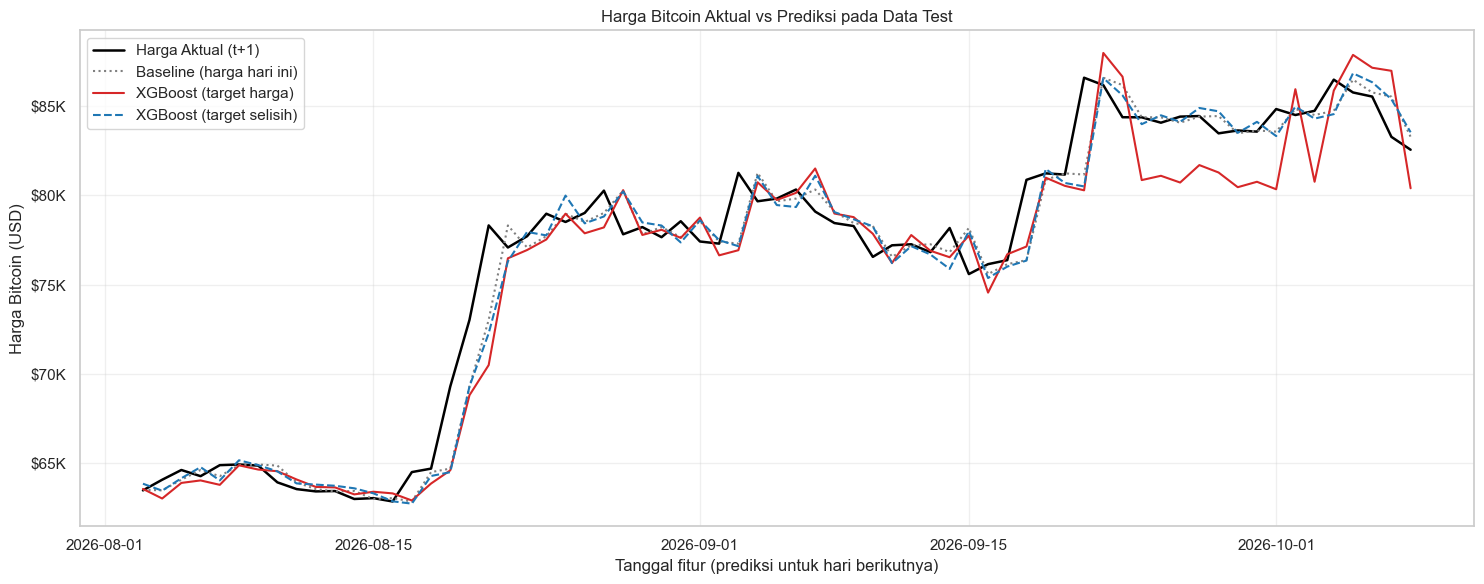

In [129]:
# VISUALISASI AKTUAL VS PREDIKSI

plt.figure(figsize=(15, 6))

plt.plot(test["recorded_date"], y_test.values, color="black", linewidth=1.8, label="Harga Aktual (t+1)")
plt.plot(test["recorded_date"], pred_baseline, color="gray", linestyle=":", label=NAMA_BASE)
plt.plot(test["recorded_date"], pred_xgb, color="tab:red", label=NAMA_XGB)
plt.plot(test["recorded_date"], pred_delta, color="tab:blue", linestyle="--", label=NAMA_DELTA)

plt.title("Harga Bitcoin Aktual vs Prediksi pada Data Test")
plt.xlabel("Tanggal fitur (prediksi untuk hari berikutnya)")
plt.ylabel("Harga Bitcoin (USD)")

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

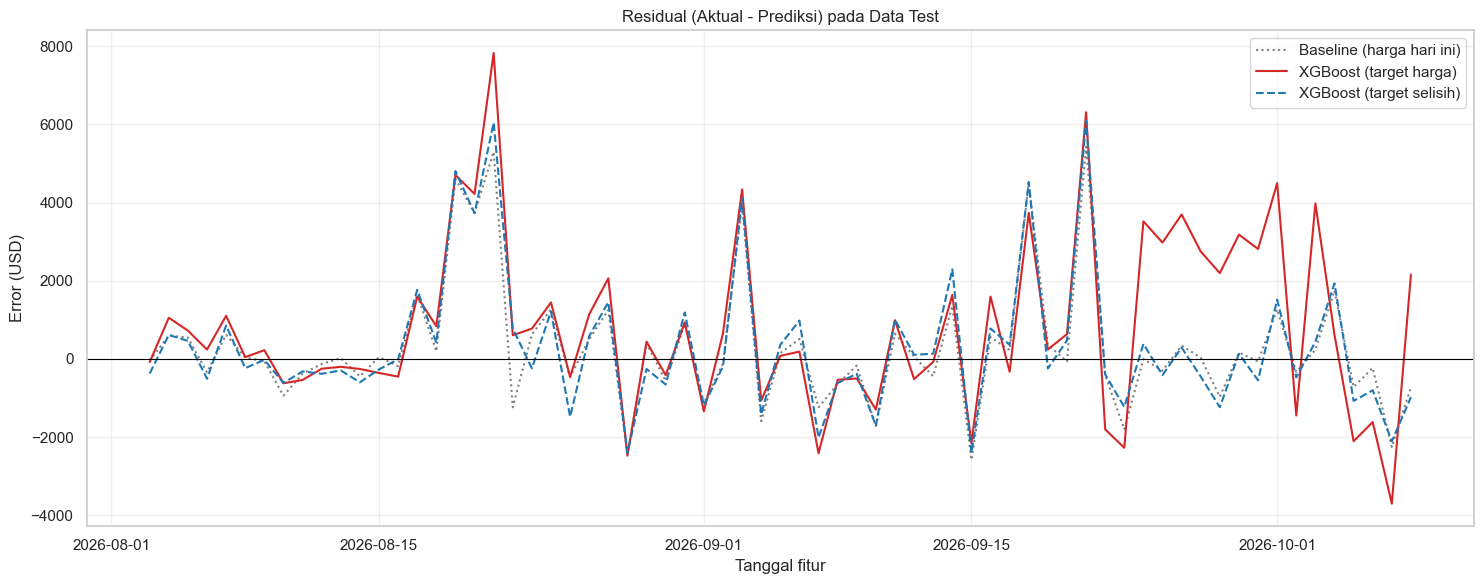

Rata-rata residual XGBoost (bias): 797.63 USD
(positif = model cenderung memprediksi terlalu rendah, negatif = terlalu tinggi)


In [130]:
# VISUALISASI RESIDUAL

residual_base = y_test.values - pred_baseline
residual_xgb = y_test.values - pred_xgb
residual_delta = y_test.values - pred_delta

plt.figure(figsize=(15, 6))

plt.plot(test["recorded_date"], residual_base, color="gray", linestyle=":", label=NAMA_BASE)
plt.plot(test["recorded_date"], residual_xgb, color="tab:red", label=NAMA_XGB)
plt.plot(test["recorded_date"], residual_delta, color="tab:blue", linestyle="--", label=NAMA_DELTA)
plt.axhline(0, color="black", linewidth=0.8)

plt.title("Residual (Aktual - Prediksi) pada Data Test")
plt.xlabel("Tanggal fitur")
plt.ylabel("Error (USD)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Rata-rata residual XGBoost (bias): {residual_xgb.mean():,.2f} USD")
print("(positif = model cenderung memprediksi terlalu rendah, negatif = terlalu tinggi)")

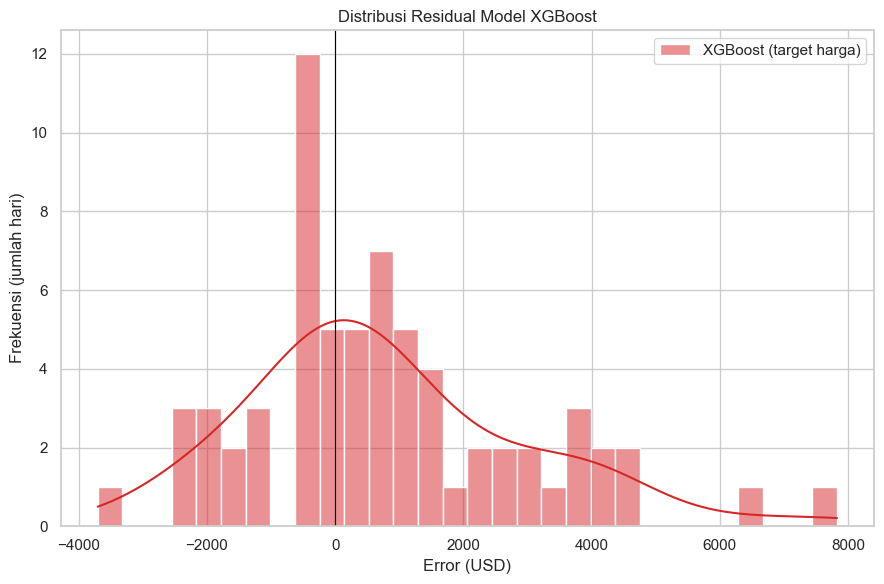

In [131]:
# DISTRIBUSI RESIDUAL XGBOOST

plt.figure(figsize=(9, 6))

sns.histplot(residual_xgb, bins=30, kde=True, color="tab:red", label=NAMA_XGB)
plt.axvline(0, color="black", linewidth=0.8)

plt.title("Distribusi Residual Model XGBoost")
plt.xlabel("Error (USD)")
plt.ylabel("Frekuensi (jumlah hari)")

plt.legend()
plt.tight_layout()
plt.show()

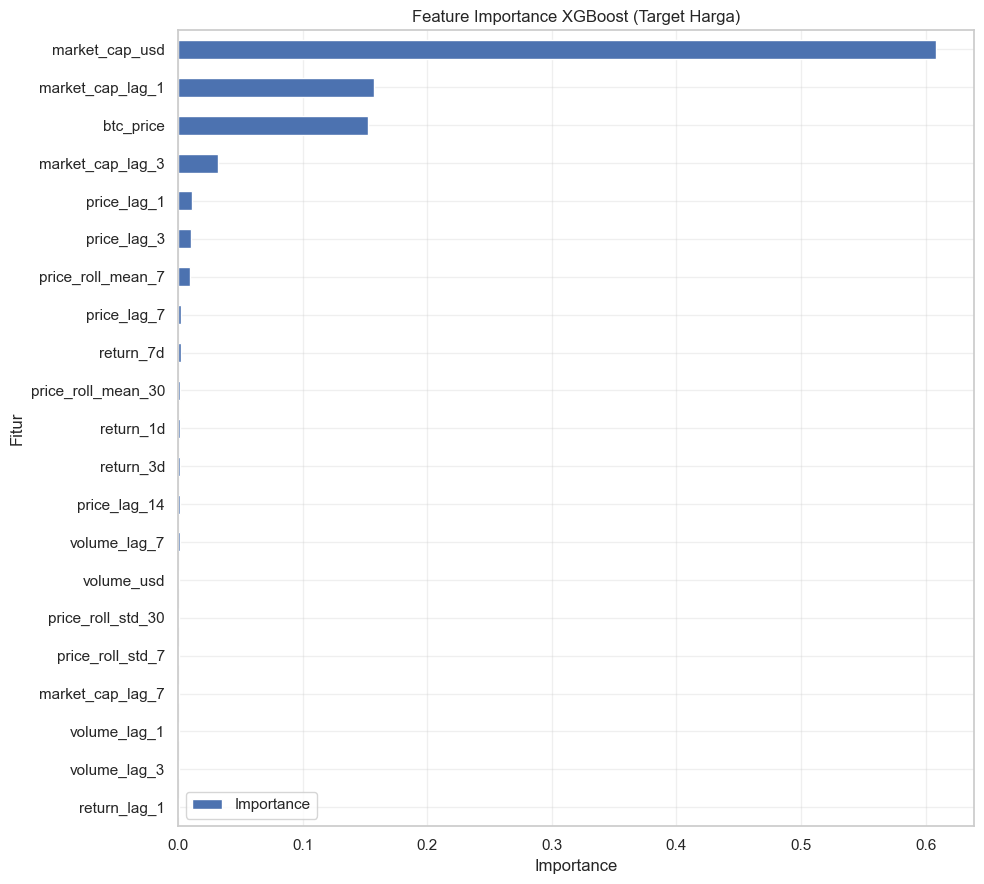

,importance
market_cap_usd,0.6085
market_cap_lag_1,0.1571
btc_price,0.1525
market_cap_lag_3,0.0323
price_lag_1,0.0108
price_lag_3,0.0107
price_roll_mean_7,0.0099
price_lag_7,0.0026
return_7d,0.0024
price_roll_mean_30,0.0014


Catatan: importance menunjukkan seberapa besar fitur dipakai model, bukan hubungan sebab-akibat. Fitur yang saling berkorelasi tinggi (harga, lag harga, rolling mean) saling membagi importance.


In [132]:
# FEATURE IMPORTANCE

importance = (
    pd.Series(model.feature_importances_, index=FITUR)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 9))
importance.plot(kind="barh", label="Importance")

plt.title("Feature Importance XGBoost (Target Harga)")
plt.xlabel("Importance")
plt.ylabel("Fitur")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(importance.sort_values(ascending=False).head(10).to_frame("importance"))

print("Catatan: importance menunjukkan seberapa besar fitur dipakai model, bukan hubungan sebab-akibat. "
      "Fitur yang saling berkorelasi tinggi (harga, lag harga, rolling mean) saling membagi importance.")

In [133]:
# CONTOH HASIL PREDIKSI DAN ERROR

evaluation = pd.DataFrame({
    "tanggal_target": (test["recorded_date"] + pd.Timedelta(days=1)).dt.date.values,
    "actual": y_test.values,
    "prediction": pred_xgb,
})

evaluation["error"] = evaluation["actual"] - evaluation["prediction"]
evaluation["absolute_error"] = evaluation["error"].abs()
evaluation["error_pct"] = evaluation["error"] / evaluation["actual"] * 100

display(evaluation.head(10))
display(evaluation.tail(10))

,tanggal_target,actual,prediction,error,absolute_error,error_pct
0,2026-08-04,"63,465.1997","63,547.4141",-82.2144,82.2144,-0.1295
1,2026-08-05,"64,062.1737","63,010.1719","1,052.0019","1,052.0019",1.6422
2,2026-08-06,"64,608.7054","63,884.1289",724.5765,724.5765,1.1215
3,2026-08-07,"64,262.7483","64,023.9453",238.8030,238.8030,0.3716
4,2026-08-08,"64,879.7561","63,776.5352","1,103.2209","1,103.2209",1.7004
5,2026-08-09,"64,917.2393","64,871.8086",45.4307,45.4307,0.0700
6,2026-08-10,"64,856.0978","64,633.1719",222.9260,222.9260,0.3437
7,2026-08-11,"63,915.7121","64,539.0391",-623.3269,623.3269,-0.9752
8,2026-08-12,"63,537.5599","64,076.3125",-538.7526,538.7526,-0.8479
9,2026-08-13,"63,408.6257","63,659.3242",-250.6985,250.6985,-0.3954


,tanggal_target,actual,prediction,error,absolute_error,error_pct
57,2026-09-30,"83,640.1016","80,460.5547","3,179.5469","3,179.5469",3.8015
58,2026-10-01,"83,576.1346","80,764.4609","2,811.6737","2,811.6737",3.3642
59,2026-10-02,"84,841.6663","80,344.5078","4,497.1585","4,497.1585",5.3006
60,2026-10-03,"84,506.4690","85,954.2969","-1,447.8279","1,447.8279",-1.7133
61,2026-10-04,"84,742.7864","80,765.6250","3,977.1614","3,977.1614",4.6932
62,2026-10-05,"86,489.7348","85,877.2734",612.4614,612.4614,0.7081
63,2026-10-06,"85,770.8722","87,876.8516","-2,105.9793","2,105.9793",-2.4554
64,2026-10-07,"85,540.0871","87,156.5703","-1,616.4832","1,616.4832",-1.8897
65,2026-10-08,"83,282.0454","86,984.4531","-3,702.4077","3,702.4077",-4.4456
66,2026-10-09,"82,560.5720","80,400.9375","2,159.6345","2,159.6345",2.6158


### Insight:
* XGBoost (target harga) TIDAK mengungguli baseline pada kedua metrik galat: MAE 1,672.34 vs 1,023.98, RMSE 2,312.06 vs 1,643.51.
* R2 XGBoost = 0.9100 dan R2 baseline = 0.9545. R2 pada harga level cenderung tinggi karena harga sangat berautokorelasi, sehingga R2 positif belum membuktikan model akurat. Pembanding yang tepat adalah baseline.
* MAPE XGBoost = 2.112% (baseline 1.321%). Akurasi arah XGBoost = 41.79% (sekitar 50% berarti setara tebakan acak).
* Varian target selisih: MAE 1,169.53, RMSE 1,777.18, R2 0.9468, akurasi arah 41.79%.
* 0.00% target testing berada di luar rentang harga training. Semakin besar persentasenya, semakin sulit bagi model berbasis pohon karena tidak dapat mengekstrapolasi.
* Harga Bitcoin dipengaruhi faktor eksternal (berita, regulasi, sentimen) yang tidak ada pada fitur, sehingga kinerja pada data testing tidak menjamin kinerja pada periode berikutnya.

# Prediksi Satu Hari Berikutnya

Model dilatih ulang dengan seluruh data historis yang memiliki target valid, memakai hyperparameter hasil tuning pada data training.
Prediksi dibuat dari fitur pada tanggal terakhir, sehingga tidak ada nilai market cap, volume, atau supply masa depan yang digunakan.

In [134]:
# MODEL FINAL (SELURUH DATA) DAN PREDIKSI SATU HARI BERIKUTNYA

X_semua, y_semua = model_data[FITUR], model_data[TARGET]

final_model = XGBRegressor(**PARAM_TETAP, **best_params)
final_model.fit(X_semua, y_semua)

final_model_delta = XGBRegressor(**PARAM_TETAP, **best_params)
final_model_delta.fit(X_semua, y_semua - X_semua["btc_price"])

# Fitur pada tanggal terakhir data (hanya informasi hingga tanggal tersebut)
baris_terakhir = feature_data.dropna(subset=FITUR).iloc[[-1]]

tanggal_terakhir = baris_terakhir["recorded_date"].iloc[0]
if tanggal_terakhir != feature_data["recorded_date"].iloc[-1]:
    print(f"Peringatan: fitur pada tanggal terakhir tidak lengkap, prediksi dibuat dari {tanggal_terakhir.date()}.")

harga_terakhir = float(baris_terakhir["btc_price"].iloc[0])
tanggal_target = tanggal_terakhir + pd.Timedelta(days=1)

pred_utama = float(final_model.predict(baris_terakhir[FITUR])[0])
pred_pembanding = harga_terakhir + float(final_model_delta.predict(baris_terakhir[FITUR])[0])

hasil_prediksi = {
    "tanggal_terakhir": tanggal_terakhir,
    "harga_terakhir": harga_terakhir,
    "tanggal_target": tanggal_target,
    "pred_utama": pred_utama,
    "pred_pembanding": pred_pembanding,
    "selisih_utama": pred_utama - harga_terakhir,
    "persen_utama": (pred_utama / harga_terakhir - 1) * 100,
    "selisih_pembanding": pred_pembanding - harga_terakhir,
    "persen_pembanding": (pred_pembanding / harga_terakhir - 1) * 100,
}

print(f"Tanggal terakhir data historis : {tanggal_terakhir.date()}")
print(f"Harga Bitcoin terakhir         : {harga_terakhir:,.2f} USD")
print(f"Tanggal target prediksi        : {tanggal_target.date()}")

print(f"\nPrediksi {NAMA_XGB} (model utama): {pred_utama:,.2f} USD")
print(f"  Perubahan nominal    : {hasil_prediksi['selisih_utama']:+,.2f} USD")
print(f"  Perubahan persentase : {hasil_prediksi['persen_utama']:+.2f}%")

print(f"\nPrediksi {NAMA_DELTA} (pembanding): {pred_pembanding:,.2f} USD")
print(f"  Perubahan nominal    : {hasil_prediksi['selisih_pembanding']:+,.2f} USD")
print(f"  Perubahan persentase : {hasil_prediksi['persen_pembanding']:+.2f}%")

print(f"\nGambaran ketidakpastian: MAE model utama pada data testing adalah {tabel_metrik.loc[NAMA_XGB, 'MAE']:,.2f} USD.")

Tanggal terakhir data historis : 2026-10-09
Harga Bitcoin terakhir         : 82,560.57 USD
Tanggal target prediksi        : 2026-10-10

Prediksi XGBoost (target harga) (model utama): 82,018.64 USD
  Perubahan nominal    : -541.93 USD
  Perubahan persentase : -0.66%

Prediksi XGBoost (target selisih) (pembanding): 82,675.53 USD
  Perubahan nominal    : +114.96 USD
  Perubahan persentase : +0.14%

Gambaran ketidakpastian: MAE model utama pada data testing adalah 1,672.34 USD.


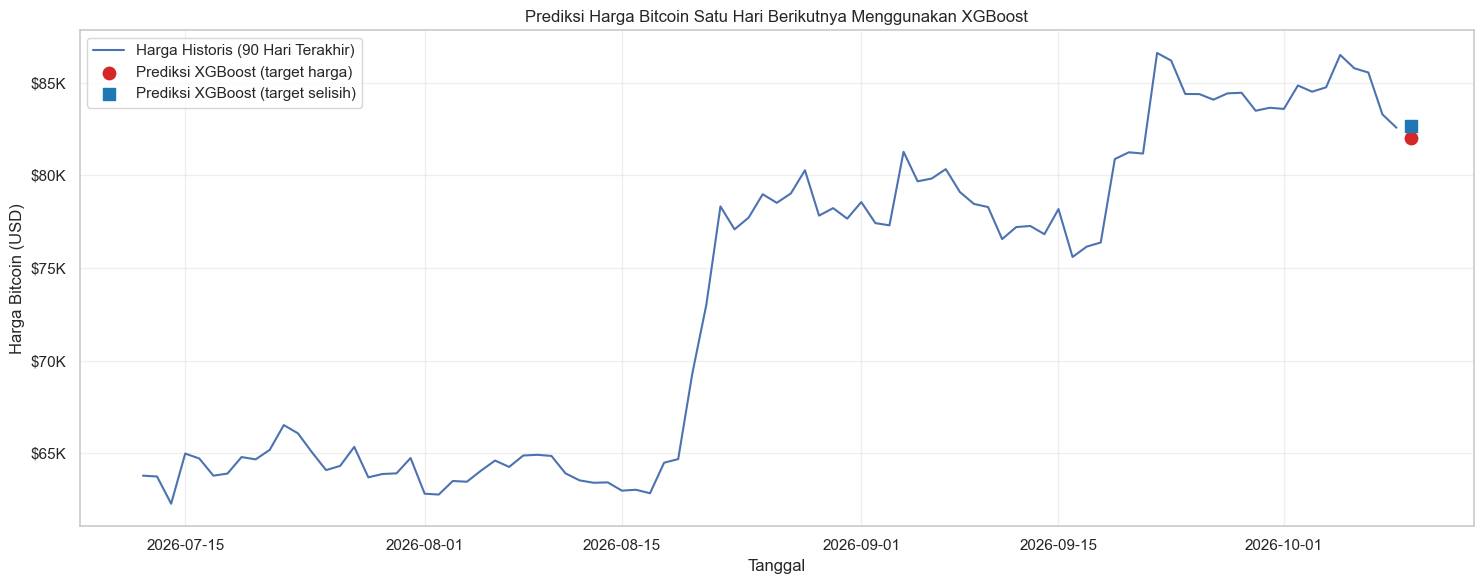

In [135]:
# VISUALISASI PREDIKSI SATU HARI BERIKUTNYA

riwayat = df_btc.iloc[-90:]

plt.figure(figsize=(15, 6))

plt.plot(riwayat["recorded_date"], riwayat["btc_price"], label="Harga Historis (90 Hari Terakhir)")
plt.scatter([hasil_prediksi["tanggal_target"]], [hasil_prediksi["pred_utama"]],
            color="tab:red", s=80, zorder=5, label=f"Prediksi {NAMA_XGB}")
plt.scatter([hasil_prediksi["tanggal_target"]], [hasil_prediksi["pred_pembanding"]],
            color="tab:blue", marker="s", s=70, zorder=5, label=f"Prediksi {NAMA_DELTA}")

plt.title("Prediksi Harga Bitcoin Satu Hari Berikutnya Menggunakan XGBoost")
plt.xlabel("Tanggal")
plt.ylabel("Harga Bitcoin (USD)")

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusion

### Jawaban Pertanyaan Bisnis

1. Perkembangan historis (2025-10-10 s.d. 2026-10-09, 365 hari).
Harga Bitcoin berubah -32.17% dari 121,718.67 USD menjadi 82,560.57 USD
(tertinggi 121,718.67 USD pada 2025-10-10, terendah 58,566.09 USD pada 2026-07-01).
Market capitalization berubah -31.60% dan volume perdagangan berubah -43.68%
(koefisien variasi volume 54.3%).

2. Korelasi antarvariabel.
Korelasi Pearson dengan harga (level): Market Cap r = 1.00 (sangat kuat, positif); Volume r = 0.50 (sedang, positif).
Korelasi pada perubahan harian: Market Cap r = 1.00 (sangat kuat, positif); Volume r = -0.00 (sangat lemah, negatif).
Korelasi pada level dapat dipengaruhi tren bersama. Market capitalization juga berkaitan secara matematis dengan harga Bitcoin dan jumlah koin yang beredar. Hasil korelasi tidak menunjukkan hubungan sebab-akibat.

3. Volatilitas dan perubahan harga.
Volatilitas harian return sebesar 2.34% (setara sekitar 44.6% per tahun). Fluktuasi tertinggi terjadi pada 2026-02 (4.33% per hari) dan terendah pada 2026-05 (1.36% per hari).
Hubungan dengan return hari berikutnya: perubahan volume: r = 0.001 (sangat lemah, positif, tidak signifikan pada alpha 5%); perubahan market cap: r = -0.008 (sangat lemah, negatif, tidak signifikan pada alpha 5%).

4. Performa XGBoost.
XGBoost tidak mengungguli baseline sederhana pada data testing (MAE 1,672.34 vs 1,023.98; RMSE 2,312.06 vs 1,643.51; MAPE 2.11% vs 1.32%; R2 0.910 vs 0.955).
Akurasi arah XGBoost 41.8%. Varian target selisih menghasilkan MAE 1,169.53 dan RMSE 1,777.18.
Sebanyak 0.0% target testing berada di luar rentang harga training, yang menyulitkan model berbasis pohon.
Kinerja model perlu dinilai menggunakan baseline dan seluruh metrik evaluasi, bukan berdasarkan nilai R2 saja.

5. Prediksi satu hari berikutnya.
Dari harga terakhir 82,560.57 USD pada 2026-10-09, model utama mengestimasi harga pada 2026-10-10 sebesar 82,018.64 USD (-541.93 USD atau -0.66%).
Model pembanding mengestimasi 82,675.53 USD (+0.14%).
Angka ini merupakan estimasi model, bukan kepastian, dan dapat meleset karena volatilitas pasar.

6. Keterbatasan data dan model.
* Data mencakup satu aset, tiga variabel utama, dan frekuensi harian dalam periode pengamatan.
* Nilai market cap atau volume yang kosong diisi dengan forward fill sehingga nilainya dapat tertinggal dari kondisi sebenarnya.
* Fitur tidak memuat faktor eksternal seperti sentimen, berita, regulasi, kondisi makroekonomi, atau data on-chain.
* Model berbasis pohon memiliki keterbatasan dalam mengekstrapolasi harga di luar rentang data training, dan evaluasi hanya memakai satu pembagian training-testing.
* Harga bersifat non-stasioner dan rezim pasar dapat berubah, sehingga kinerja masa lalu tidak menjamin kinerja masa depan.

7. Rekomendasi pengembangan.

* Gunakan walk-forward validation dengan beberapa jendela waktu untuk evaluasi yang lebih andal.
* Tambahkan fitur teknikal (RSI, MACD, Bollinger Bands) dan fitur eksternal (sentimen, data on-chain, indeks pasar).
* Coba target berupa return atau log-return, serta bandingkan dengan LightGBM, Random Forest, ARIMA, atau LSTM.
* Otomatiskan pelatihan dan prediksi harian sebagai task baru pada DAG Airflow, lengkap dengan pemantauan galat model.
* Gunakan prediksi sebagai alat bantu analisis, bukan sebagai dasar tunggal keputusan investasi.